# Exploratory Data Analysis, Home Credit Default Risk

**Project:** Knowledge Discovery in Banking Dataset
**Phase:** 1, Data Understanding & Preprocessing
**Step:** 1, EDA & Analytical Justification
**Dataset:** Home Credit Default Risk (Kaggle)

---

Everything downstream rests on this notebook. Before we clean or transform anything, we need to understand what the data actually is: how the tables fit together, where values go missing and why, which numbers are real extremes versus data-entry mistakes, and what each quirk means in a banking context.

So this is a diagnosis, not a treatment. We do not change a single value here. We read the data closely, write down what we find, and turn each finding into a specific, justified decision for the preprocessing pipeline in Step 2. If a choice in Step 2 looks surprising, it should be traceable back to a paragraph in this notebook.

## Setup, Libraries and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

In [2]:
DATA = '../datasets/'

# The portfolio is one population. The first source file carries a loan-outcome
# column from its original competition packaging; this project analyzes the
# applications as an unlabeled portfolio, so that column is removed at load and
# nothing downstream ever reads it.
app_part_a = pd.read_csv(DATA + 'application_train.csv').drop(columns=['TARGET'])
app_part_b = pd.read_csv(DATA + 'application_test.csv')
app = pd.concat([app_part_a, app_part_b], ignore_index=True, sort=False)
del app_part_a, app_part_b

bureau     = pd.read_csv(DATA + 'bureau.csv')
bureau_bal = pd.read_csv(DATA + 'bureau_balance.csv')
prev       = pd.read_csv(DATA + 'previous_application.csv')
pos        = pd.read_csv(DATA + 'POS_CASH_balance.csv')
inst       = pd.read_csv(DATA + 'installments_payments.csv')
cc         = pd.read_csv(DATA + 'credit_card_balance.csv')

print('All datasets loaded successfully.')
print(f'  application table : {app.shape[0]:>8,} rows x {app.shape[1]:>3} cols')
print(f'  bureau            : {bureau.shape[0]:>8,} rows x {bureau.shape[1]:>3} cols')
print(f'  bureau_balance    : {bureau_bal.shape[0]:>8,} rows x {bureau_bal.shape[1]:>3} cols')
print(f'  previous_app      : {prev.shape[0]:>8,} rows x {prev.shape[1]:>3} cols')
print(f'  POS_CASH_balance  : {pos.shape[0]:>8,} rows x {pos.shape[1]:>3} cols')
print(f'  installments      : {inst.shape[0]:>8,} rows x {inst.shape[1]:>3} cols')
print(f'  credit_card_bal   : {cc.shape[0]:>8,} rows x {cc.shape[1]:>3} cols')


All datasets loaded successfully.
  application table :  356,255 rows x 121 cols
  bureau            : 1,716,428 rows x  17 cols
  bureau_balance    : 27,299,925 rows x   3 cols
  previous_app      : 1,670,214 rows x  37 cols
  POS_CASH_balance  : 10,001,358 rows x   8 cols
  installments      : 13,605,401 rows x   8 cols
  credit_card_bal   : 3,840,312 rows x  23 cols


---
## Section 1: Dataset Orientation

### What we are checking, and why

Before looking at any single feature, we need to know what each table holds, what one row actually represents (its grain), and how the tables connect. Get the grain wrong and every later aggregation inflates or double-counts. That mistake silently propagates into clustering and rule mining, so it is worth a few minutes up front.

The files form an applicant-centred set of one-to-many histories. `application_train.csv` supplies one row per labeled application, while the related files contain bureau, previous-application, repayment, POS, and card records at different grains. We check the grain, duplicate application IDs, related-record depth, and source coverage before any joins so later aggregation does not inflate counts.

In [3]:
print('=== application table ===')
print(f'Rows: {len(app):,}  |  Columns: {app.shape[1]}')
print(f'Dtype breakdown: {dict(app.dtypes.value_counts())}')

n_unique_pk = app['SK_ID_CURR'].nunique()
print(f'\nPrimary key (SK_ID_CURR) uniqueness: {n_unique_pk:,} unique of {len(app):,} total')
print(f'Duplicate PKs: {len(app) - n_unique_pk}')

num_cols = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR'])
cat_cols = app.select_dtypes(include='object').columns
print(f'\nNumerical features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

print('\n=== Relational Table Summary ===')
n_app = app['SK_ID_CURR'].nunique()
tables = [('bureau', bureau), ('previous_application', prev),
          ('POS_CASH_balance', pos), ('installments_payments', inst),
          ('credit_card_balance', cc)]
print(f"{'Table':<28} {'Rows':>10} {'Applicants':>12} {'Missing':>10}")
print('-' * 65)
for name, df in tables:
    if 'SK_ID_CURR' in df.columns:
        n_linked = df['SK_ID_CURR'].nunique()
        n_miss = n_app - n_linked
        print(f'{name:<28} {len(df):>10,} {n_linked:>12,} {n_miss:>10,}')

print('\n=== Records-per-applicant Distribution ===')
for name, df in tables:
    if 'SK_ID_CURR' not in df.columns:
        continue
    c = df['SK_ID_CURR'].value_counts()
    print(f'{name:<28}  med={c.median():.0f}  p75={c.quantile(0.75):.0f}  p95={c.quantile(0.95):.0f}  max={c.max()}')

=== application table ===
Rows: 356,255  |  Columns: 121
Dtype breakdown: {dtype('float64'): np.int64(65), dtype('int64'): np.int64(40), <StringDtype(na_value=nan)>: np.int64(16)}

Primary key (SK_ID_CURR) uniqueness: 356,255 unique of 356,255 total
Duplicate PKs: 0

Numerical features : 104
Categorical features: 16

=== Relational Table Summary ===
Table                              Rows   Applicants    Missing
-----------------------------------------------------------------


bureau                        1,716,428      305,811     50,444
previous_application          1,670,214      338,857     17,398


POS_CASH_balance             10,001,358      337,252     19,003


installments_payments        13,605,401      339,587     16,668
credit_card_balance           3,840,312      103,558    252,697

=== Records-per-applicant Distribution ===


bureau                        med=4  p75=8  p95=14  max=116


previous_application          med=4  p75=7  p95=13  max=77


POS_CASH_balance              med=22  p75=39  p95=80  max=295


installments_payments         med=25  p75=51  p95=131  max=372


credit_card_balance           med=22  p75=75  p95=96  max=192


### What we found

**One row, one application.** Each row of the application table is a single loan application from one applicant. The key `SK_ID_CURR` has no duplicates across all 356,255 rows, so the main table is clean at the source.

**The 121 columns are fewer than they look.** Of the 121 columns, 104 are numeric and 16 categorical (plus the `SK_ID_CURR` identifier). But roughly 48 of them are building and property measurements reported three ways each (`_AVG`, `_MODE`, `_MEDI`), so the real variety is much lower than the column count suggests. That triplication matters later for both missingness and correlation.

**How much behavioural history each applicant carries:**

| Table | Behavioural dimension | Median records among matched applicants | Applications with no joined record |
|---|---|---|---|
| `bureau` | External credit history | 4 | 50,444 (14.16% of the 356,255 applications) |
| `previous_application` | Past applications | 4 | 17,398 (4.88%) |
| `POS_CASH_balance` | POS/cash repayment | 22 months | 19,003 (5.33%) |
| `installments_payments` | Installment repayment | 25 records | 16,668 (4.68%) |
| `credit_card_balance` | Revolving credit use | 22 months | 252,697 (70.92%) |

50,444 of 356,255 applications (14.16%) have no joined bureau record. That absence does not prove a thin credit file or first-time borrowing; it may also reflect source coverage, collection, or join boundaries. We keep it as an evidence-availability flag and do not treat it as adverse behaviour. The monthly snapshot tables are enormous (`bureau_balance` alone is 27.3M rows), so they must be aggregated to one row per applicant before joining. The median is 4 bureau records with a long tail, which is why aggregation, not direct joining, is the only safe way to bring this history to the applicant level.


---
## Section 2: Missing values

### What we are checking, and why

A blank can have several meanings. Missing `OWN_CAR_AGE` is structurally tied to not owning a car, while missing `EXT_SOURCE_1` only tells us that this score is unavailable in the supplied data. It does not prove weak credit history or payment risk. For each field we separate structural absence, measurement uncertainty, and possible source-data gaps before choosing a treatment.

We sort columns into four bands by how much is missing: under 5%, 5 to 30%, 30 to 60%, and over 60%. The bands organise the investigation; they do not choose the treatment. Even a small gap is reviewed by field meaning and missingness mechanism, with a separate flag where absence carries information.

Missingness tier summary:
  Tier 1 (<5%): 10 columns
  Tier 2 (5-30%): 7 columns
  Tier 3 (30-60%): 33 columns
  Tier 4 (>60%): 17 columns
  No missing: 54 columns


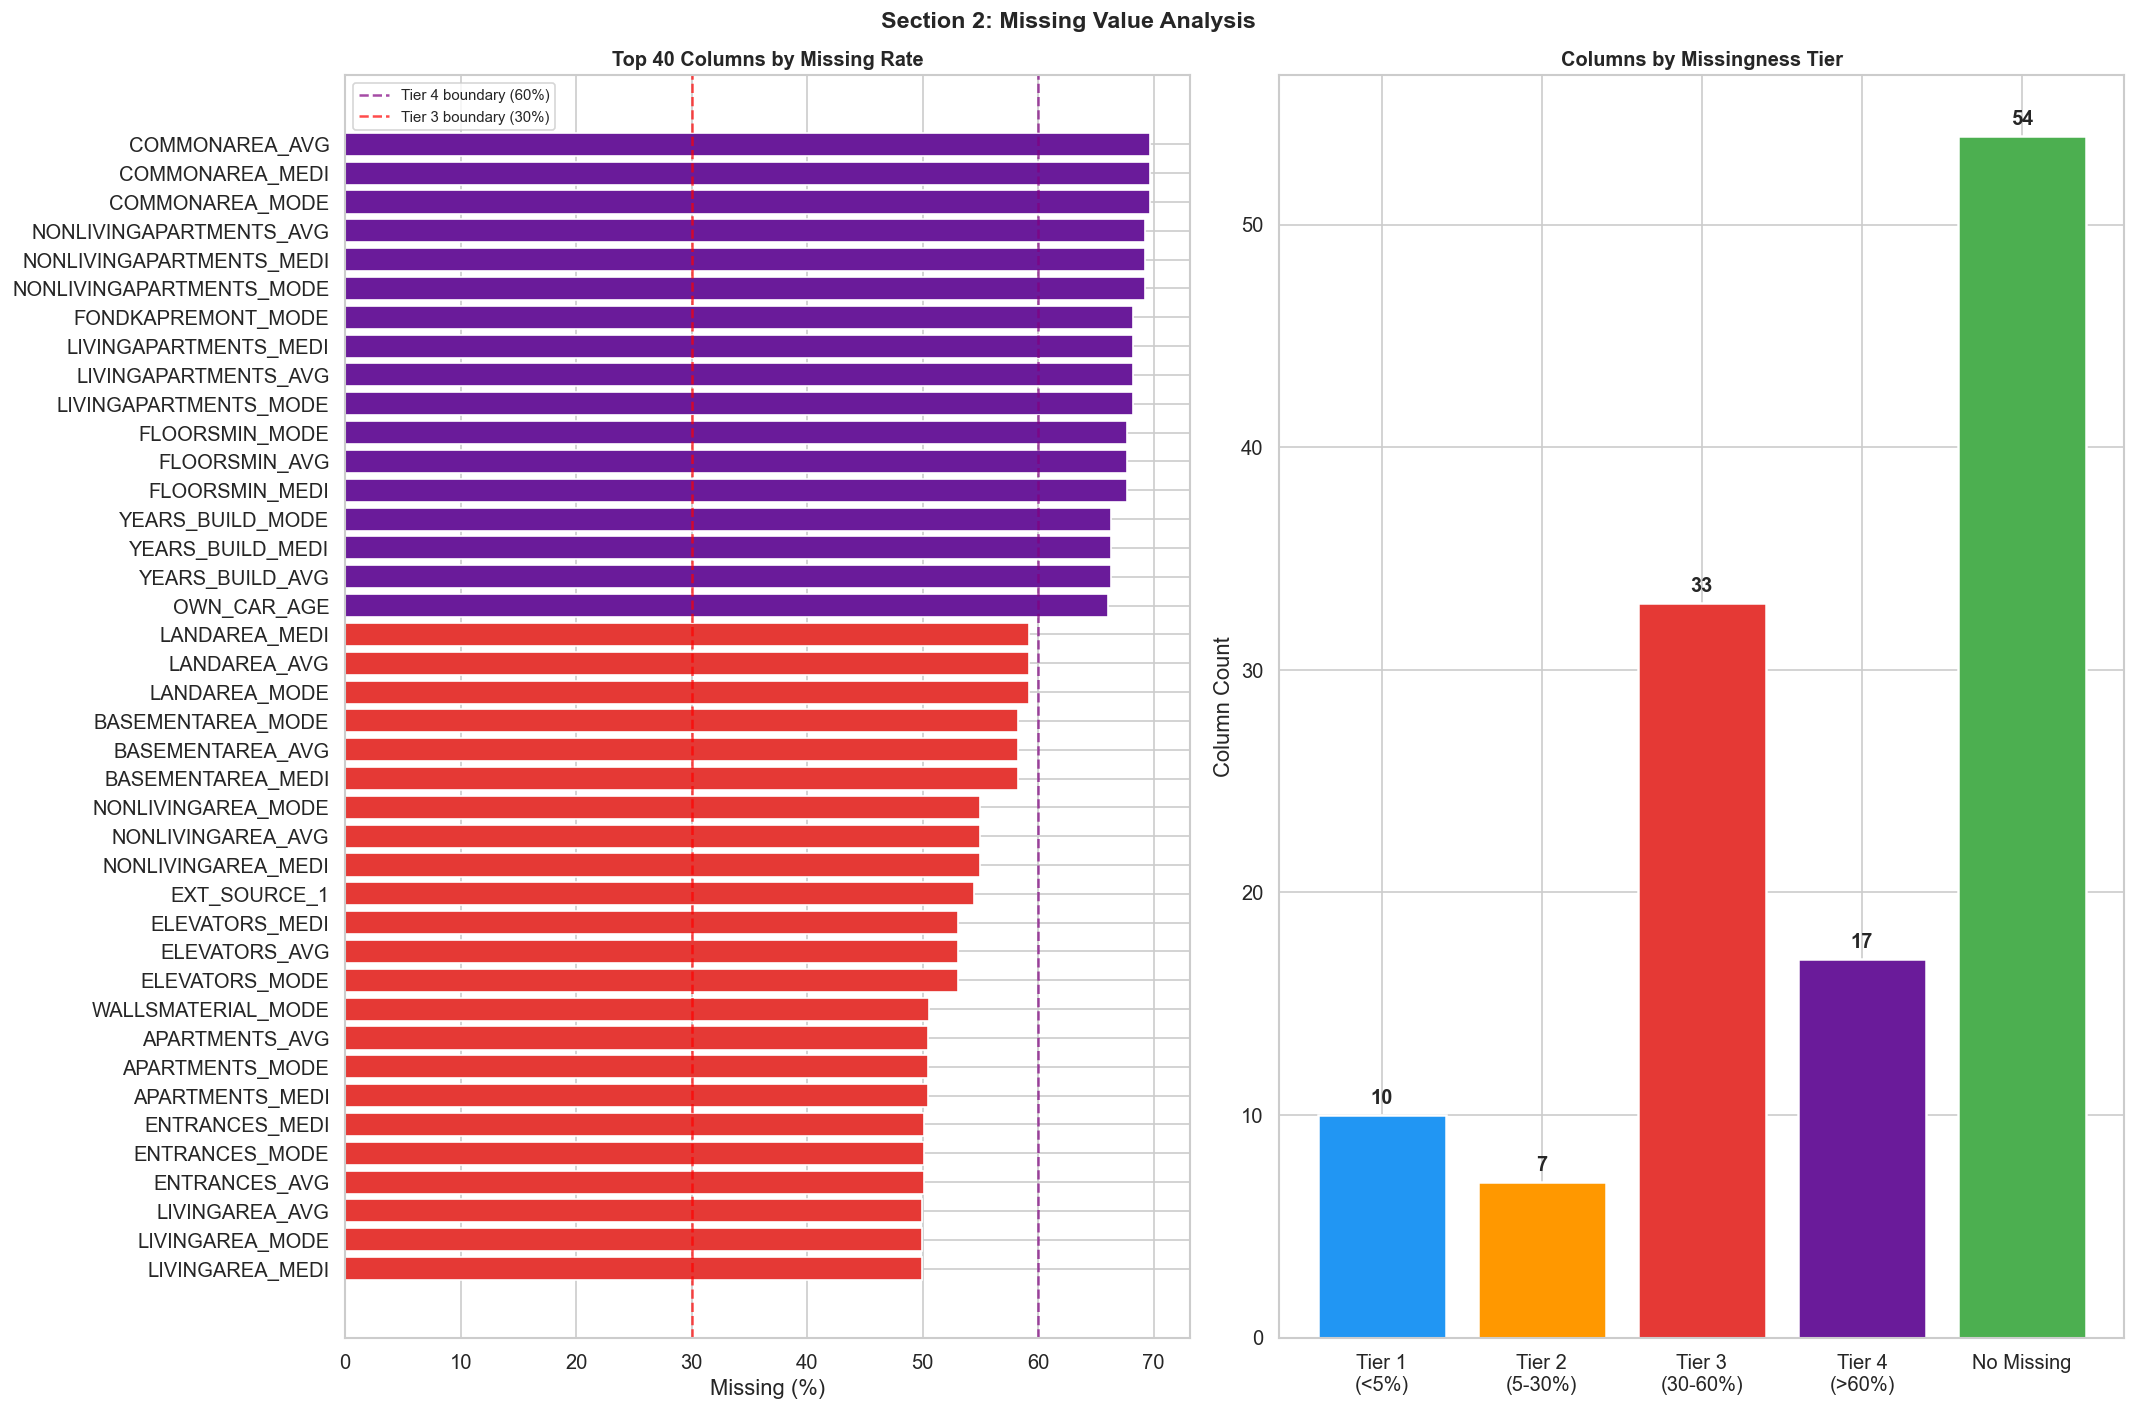


--- Key domain columns ---
  EXT_SOURCE_1                       : 54.43%
  EXT_SOURCE_2                       : 0.19%
  EXT_SOURCE_3                       : 19.55%
  OWN_CAR_AGE                        : 66.03%
  OCCUPATION_TYPE                    : 31.44%
  AMT_ANNUITY                        : 0.01%
  AMT_GOODS_PRICE                    : 0.08%

Housing-related columns (47 total): range 47.1%-69.7%


In [4]:
missing_counts = app.isnull().sum()
missing_pct    = (missing_counts / len(app) * 100).round(2)
missing_df = pd.DataFrame({'count': missing_counts, 'pct': missing_pct}) \
               .sort_values('pct', ascending=False)
missing_df = missing_df[missing_df['count'] > 0]

def tier(pct):
    if pct < 5:  return 'Tier 1 (<5%)'
    if pct < 30: return 'Tier 2 (5-30%)'
    if pct < 60: return 'Tier 3 (30-60%)'
    return              'Tier 4 (>60%)'

missing_df['tier'] = missing_df['pct'].apply(tier)
tier_counts = missing_df['tier'].value_counts()
print('Missingness tier summary:')
for t in ['Tier 1 (<5%)', 'Tier 2 (5-30%)', 'Tier 3 (30-60%)', 'Tier 4 (>60%)', 'No missing']:
    if t == 'No missing':
        print(f'  {t}: {app.shape[1] - len(missing_df)} columns')
    else:
        print(f'  {t}: {tier_counts.get(t, 0)} columns')

tier_colors = {'Tier 1 (<5%)': '#2196F3', 'Tier 2 (5-30%)': '#FF9800',
               'Tier 3 (30-60%)': '#E53935', 'Tier 4 (>60%)': '#6A1B9A'}

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

top_miss = missing_df.head(40)
colors = [tier_colors[t] for t in top_miss['tier']]
ax = axes[0]
ax.barh(top_miss.index[::-1], top_miss['pct'][::-1], color=colors[::-1])
ax.axvline(60, color='purple', linestyle='--', alpha=0.7, label='Tier 4 boundary (60%)')
ax.axvline(30, color='red',    linestyle='--', alpha=0.7, label='Tier 3 boundary (30%)')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 40 Columns by Missing Rate', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
tier_labels = ['Tier 1\n(<5%)', 'Tier 2\n(5-30%)', 'Tier 3\n(30-60%)', 'Tier 4\n(>60%)', 'No Missing']
tier_vals   = [tier_counts.get('Tier 1 (<5%)', 0), tier_counts.get('Tier 2 (5-30%)', 0),
               tier_counts.get('Tier 3 (30-60%)', 0), tier_counts.get('Tier 4 (>60%)', 0),
               app.shape[1] - len(missing_df)]
tier_col    = ['#2196F3', '#FF9800', '#E53935', '#6A1B9A', '#4CAF50']
bars = ax.bar(tier_labels, tier_vals, color=tier_col, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tier_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Columns by Missingness Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Column Count')

plt.suptitle('Section 2: Missing Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Key domain columns ---')
key_domain = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','OWN_CAR_AGE','OCCUPATION_TYPE','AMT_ANNUITY','AMT_GOODS_PRICE']
for col in key_domain:
    print(f'  {col:<35}: {missing_pct.get(col, 0):.2f}%')
house_cols = [c for c in app.columns if any(s in c for s in ['_AVG','_MODE','_MEDI'])]
print(f'\nHousing-related columns ({len(house_cols)} total): range {missing_pct[house_cols].min():.1f}%-{missing_pct[house_cols].max():.1f}%')

### What we found

About 55% of columns (67 of 121) have at least some missing values. The pattern is concentrated in a few source blocks, but the supplied dictionary does not document every cause, so the analysis preserves availability flags without inventing an applicant-level explanation.

**Over 60% missing (17 columns).** Sixteen are building/property measurements (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`) and one is `OWN_CAR_AGE`. The building fields disappear together, but the supplied dictionary does not establish whether absence means housing type, unavailable registry coverage, non-collection, or another process. One availability flag preserves the distinction without assigning a cause.

`OWN_CAR_AGE` (66% missing) is a different story: it is blank precisely when the applicant owns no car (`FLAG_OWN_CAR = 'N'`). The blank carries the same information as car ownership itself, so before doing anything else we create `FLAG_NO_CAR` from it.

**30 to 60% missing (33 columns).** The 47 housing columns sit between 47 and 70% missing, and they go missing together: if `APARTMENTS_AVG` is blank, its `_MEDI` and `_MODE` twins are blank too, at the same rate.

`EXT_SOURCE_1` (an external score supplied without documentation of how it is built) is missing for 54.4% of rows, and a blank has no documented cause in this dataset. We create `FLAG_EXT_SOURCE_1_MISSING` to preserve score availability before imputation, and interpret that flag as uncertainty rather than adverse evidence. `OCCUPATION_TYPE` (31.4% missing) is handled as a collection gap.

The practical takeaway for the housing block: keep one statistical variant (`_MODE`), drop the redundant `_AVG` and `_MEDI`, and represent the whole block's absence with a single flag rather than 47 separate ones.

---
## Section 3: Numeric feature distributions

### What we are checking, and why

The shape of a distribution decides how we should treat it. Right-skewed income needs a log transform before any distance-based clustering, otherwise a handful of millionaires dominate every distance. Negative `DAYS_EMPLOYED` values are valid (they are elapsed time) but only make sense once you know the encoding. And an impossible extreme is not just a statistical outlier, it is a data-quality flag.

We look at the descriptive statistics, the skewness and kurtosis, and the distributions of the features that carry the most weight downstream.

In [5]:
num_cols = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR'])

desc = app[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc['skewness'] = app[num_cols].skew()
desc['kurtosis'] = app[num_cols].kurtosis()

print('Key financial feature statistics:')
key_show = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
            'DAYS_BIRTH','DAYS_EMPLOYED','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
print(desc.loc[[c for c in key_show if c in desc.index],
               ['mean','50%','99%','max','skewness']].to_string())

print(f'\nFeatures with extreme skewness (|skew|>2, excluding binary flags):')
high_skew = desc[(abs(desc['skewness']) > 2) & (desc['max'] > 1)].sort_values('skewness', ascending=False)
print(f'Count: {len(high_skew)}')
print(high_skew[['50%','max','skewness']].head(10).to_string())

print(f'\nDAYS_EMPLOYED sentinel (365243): {(app["DAYS_EMPLOYED"]==365243).sum():,} records ({(app["DAYS_EMPLOYED"]==365243).mean()*100:.2f}%)')
print(f'Age range (years): {abs(app["DAYS_BIRTH"].max())/365.25:.1f} to {abs(app["DAYS_BIRTH"].min())/365.25:.1f}')

Key financial feature statistics:
                         mean          50%            99%              max  skewness
AMT_INCOME_TOTAL 170,116.0599 153,000.0000   486,000.0000 117,000,000.0000  403.6497
AMT_CREDIT       587,767.4138 500,211.0000 1,858,728.6000   4,050,000.0000    1.2833
AMT_ANNUITY       27,425.5607  25,078.5000    71,370.0000     258,025.5000    1.5697
AMT_GOODS_PRICE  528,019.9978 450,000.0000 1,800,000.0000   4,050,000.0000    1.3943
DAYS_BIRTH       -16,041.2488 -15,755.0000    -8,274.0000      -7,338.0000   -0.1159
DAYS_EMPLOYED     64,317.2314  -1,224.0000   365,243.0000     365,243.0000    1.6521
EXT_SOURCE_1           0.5020       0.5062         0.8881           0.9627   -0.0772
EXT_SOURCE_2           0.5149       0.5648         0.7831           0.8550   -0.7931
EXT_SOURCE_3           0.5094       0.5335         0.8328           0.8960   -0.3986

Features with extreme skewness (|skew|>2, excluding binary flags):
Count: 12
                                    50

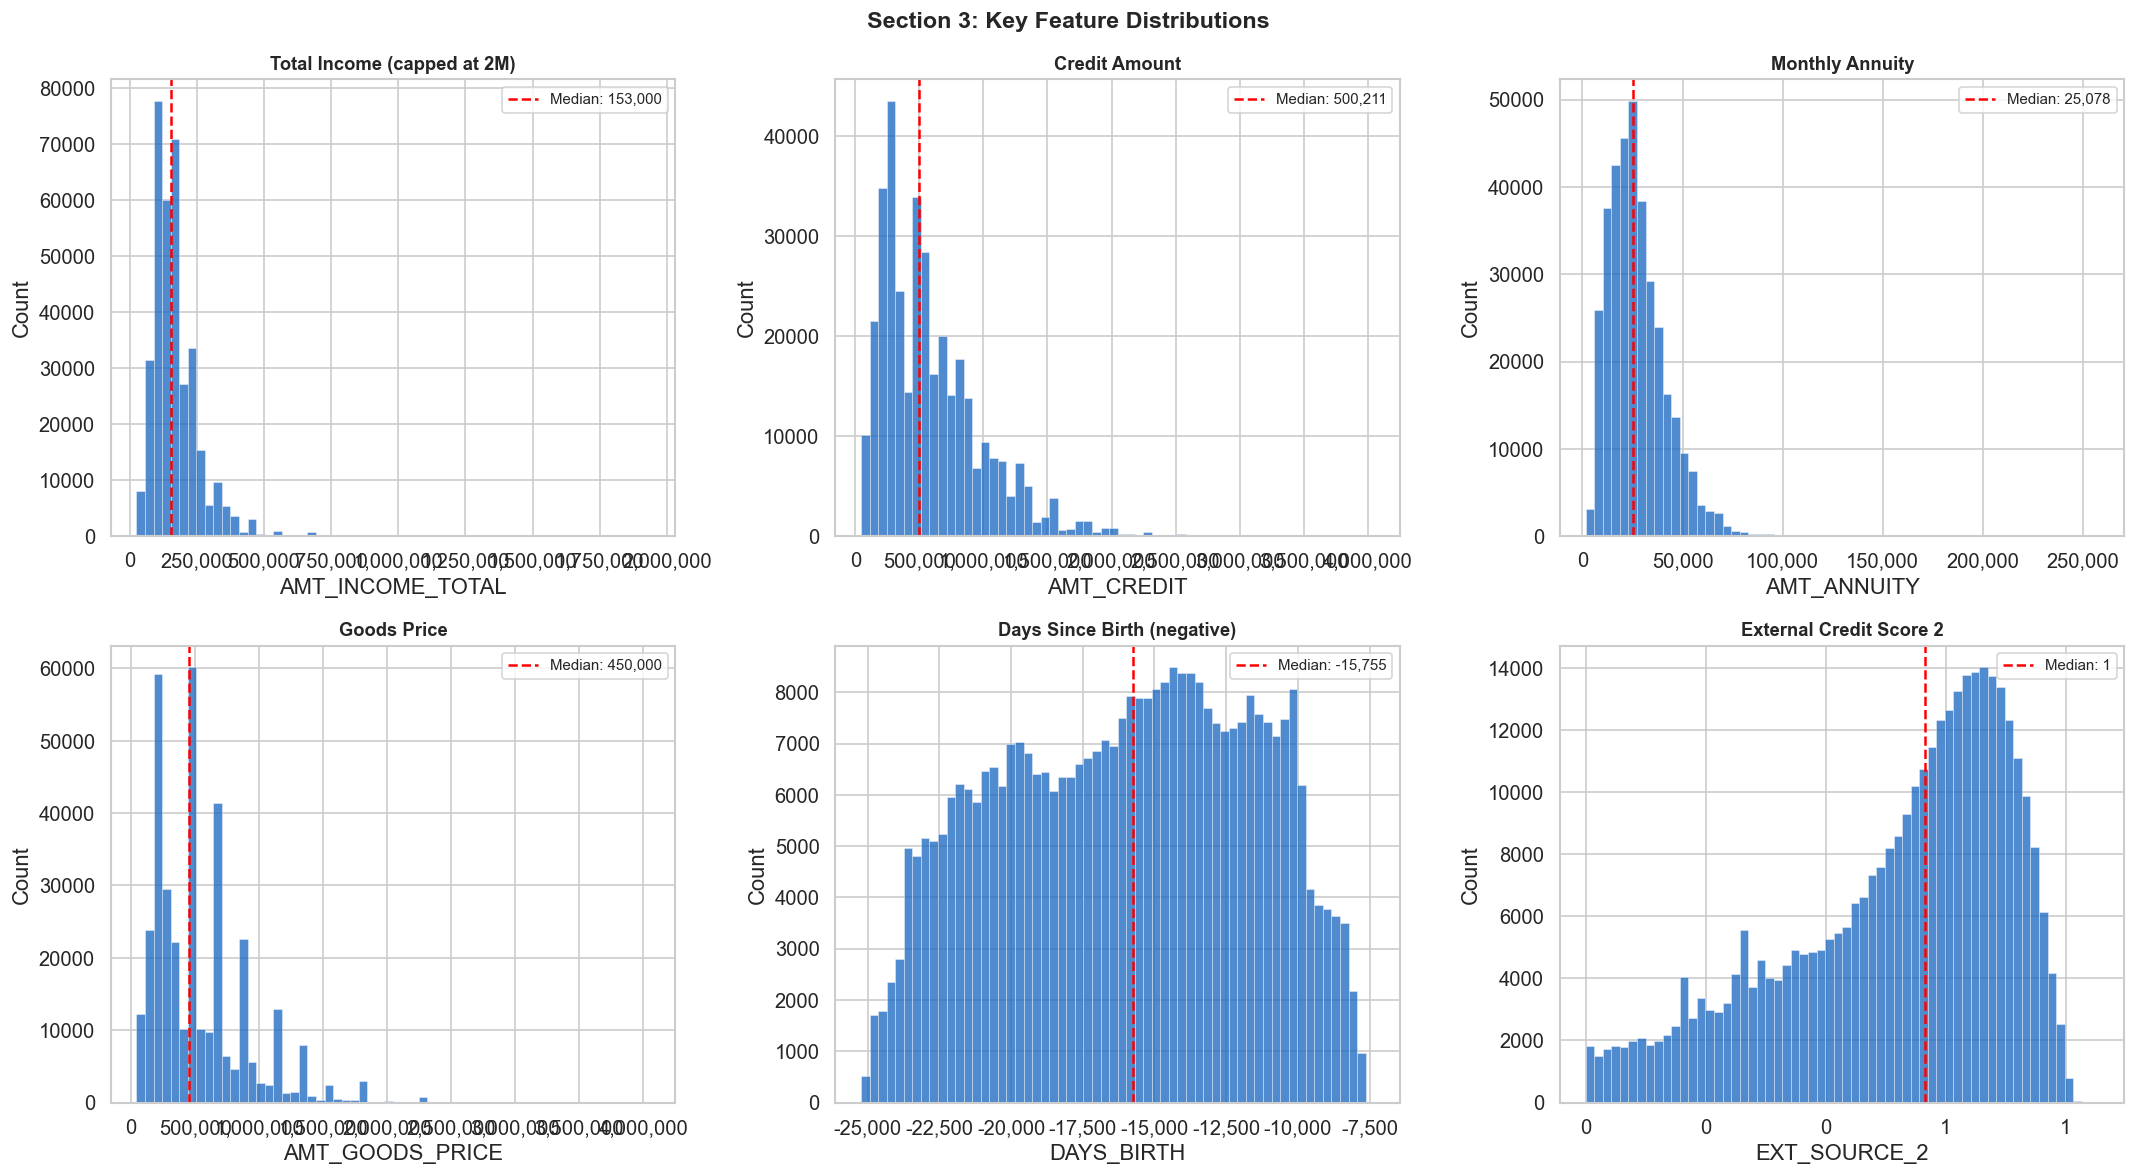

Sentinel records by income type:
NAME_INCOME_TYPE
Pensioner     64625
Unemployed       23


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_feats = [
    ('AMT_INCOME_TOTAL', 'Total Income (capped at 2M)'),
    ('AMT_CREDIT',       'Credit Amount'),
    ('AMT_ANNUITY',      'Monthly Annuity'),
    ('AMT_GOODS_PRICE',  'Goods Price'),
    ('DAYS_BIRTH',       'Days Since Birth (negative)'),
    ('EXT_SOURCE_2',     'External Credit Score 2'),
]

for ax, (col, title) in zip(axes.flat, key_feats):
    data = app[col].dropna()
    if col == 'AMT_INCOME_TOTAL': data = data[data <= 2e6]
    if col == 'DAYS_EMPLOYED':   data = data[data != 365243]
    ax.hist(data, bins=60, color='#1565C0', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():,.0f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Section 3: Key Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# DAYS_EMPLOYED sentinel breakdown
sent = app[app['DAYS_EMPLOYED'] == 365243]
print('Sentinel records by income type:')
print(sent['NAME_INCOME_TYPE'].value_counts().to_string())


### What we found

**Income (`AMT_INCOME_TOTAL`, the applicant's declared annual income) is extremely skewed.** Median 153,000, mean 170,116, maximum 117,000,000 in anonymized currency units. The jump from the 99th percentile (486,000) to that maximum points to a tiny group of ultra-high-income applicants who do not represent the population. A log transform is non-negotiable before any distance calculation, and we winsorize at the 99th percentile first so the cap does not get swallowed by the tail.

**The loan amount (`AMT_CREDIT`, the credit amount of the current application)** is right-skewed (skewness 1.28) but much milder than income. Median 500,211, max 4,050,000, with most loans bunched in the mid hundreds of thousands and a long tail. A log transform helps here too.

**The scheduled payment (`AMT_ANNUITY`, the periodic instalment amount)** is right-skewed (1.57); median 25,079, max 258,026. Its shape tracks the loan amount, which makes sense since the instalment is bounded by the loan size and rate.

**Age (`DAYS_BIRTH`, days since birth stored as a negative number)** spans ages 20.1 to 69.1 years, a clean symmetric spread with nothing anomalous. We convert it to positive years for readability.

**`DAYS_EMPLOYED` (days in current employment) hides a sentinel.** The value 365,243 (exactly 1,000 years in days) shows up in 64,648 records, 18.1% of the portfolio, and every one of them is a pensioner (64,625) or unemployed (23). This is a deliberate placeholder, not a tenure value. We replace it with a missing value and retain a structural flag so zero is not mistaken for real tenure. Because that flag can proxy life stage, it is documented as a fairness-sensitivity limitation rather than treated as a risk rule.

**External scores (`EXT_SOURCE_1/2/3`, three externally supplied creditworthiness scores of undocumented construction)** all live in [0,1]. Pairwise correlations below 0.22 show limited linear overlap, not statistical independence. The analysis keeps all three values because they are the only externally sourced summary evidence in the data. `EXT_SOURCE_1` is missing for 54.4% of rows; its availability flag records uncertainty and is not treated as bad behaviour.


---
## Section 4: Categorical features

### What we are checking, and why

Categorical variables help describe who appears in a segment after clustering. Description and formation are different jobs: gender, age, family status, region, education, income type, and organisation type remain available for fairness and coverage checks, but they do not form the segments because they are protected, life-stage, geographic, or socioeconomic proxies.

We check high cardinality, dominant categories above 90%, and catch-all codes such as `XNA`, `Other`, or `Unknown`. Encoding still matters for the readable business artifact, but only approved non-proxy fields can enter the clustering matrix.

In [7]:
cat_cols = app.select_dtypes(include='object').columns.tolist()

cat_summary = []
for col in cat_cols:
    vc = app[col].value_counts(dropna=True)
    n_unique = app[col].nunique(dropna=True)
    dominant_pct = vc.iloc[0] / len(app) * 100 if len(vc) > 0 else 0
    n_xna = app[col].isin(['XNA','Unknown','XAP','Other','not specified']).sum()
    cat_summary.append({'column': col, 'n_unique': n_unique,
                        'dominant_category': str(vc.index[0]) if len(vc)>0 else 'N/A',
                        'dominant_pct': round(dominant_pct, 1),
                        'xna_count': n_xna,
                        'missing_pct': round(app[col].isna().mean()*100, 1)})

cat_df = pd.DataFrame(cat_summary).sort_values('dominant_pct', ascending=False)
print(cat_df.to_string(index=False))

low_var = cat_df[cat_df['dominant_pct'] >= 88]
print(f'\nLow-variance categoricals (dominant >= 88%):')
for _, row in low_var.iterrows():
    print(f'  {row["column"]}: {repr(row["dominant_category"])} = {row["dominant_pct"]}%')

                    column  n_unique             dominant_category  dominant_pct  xna_count  missing_pct
        NAME_CONTRACT_TYPE         2                    Cash loans       91.7000          0       0.0000
         NAME_HOUSING_TYPE         6             House / apartment       88.8000          0       0.0000
           NAME_TYPE_SUITE         7                 Unaccompanied       80.9000          0       0.6000
       NAME_EDUCATION_TYPE         5 Secondary / secondary special       70.8000          0       0.0000
           FLAG_OWN_REALTY         2                             Y       69.3000          0       0.0000
              FLAG_OWN_CAR         2                             N       66.0000          0       0.0000
               CODE_GENDER         3                             F       66.0000          4       0.0000
        NAME_FAMILY_STATUS         6                       Married       64.2000          2       0.0000
       EMERGENCYSTATE_MODE         2                   

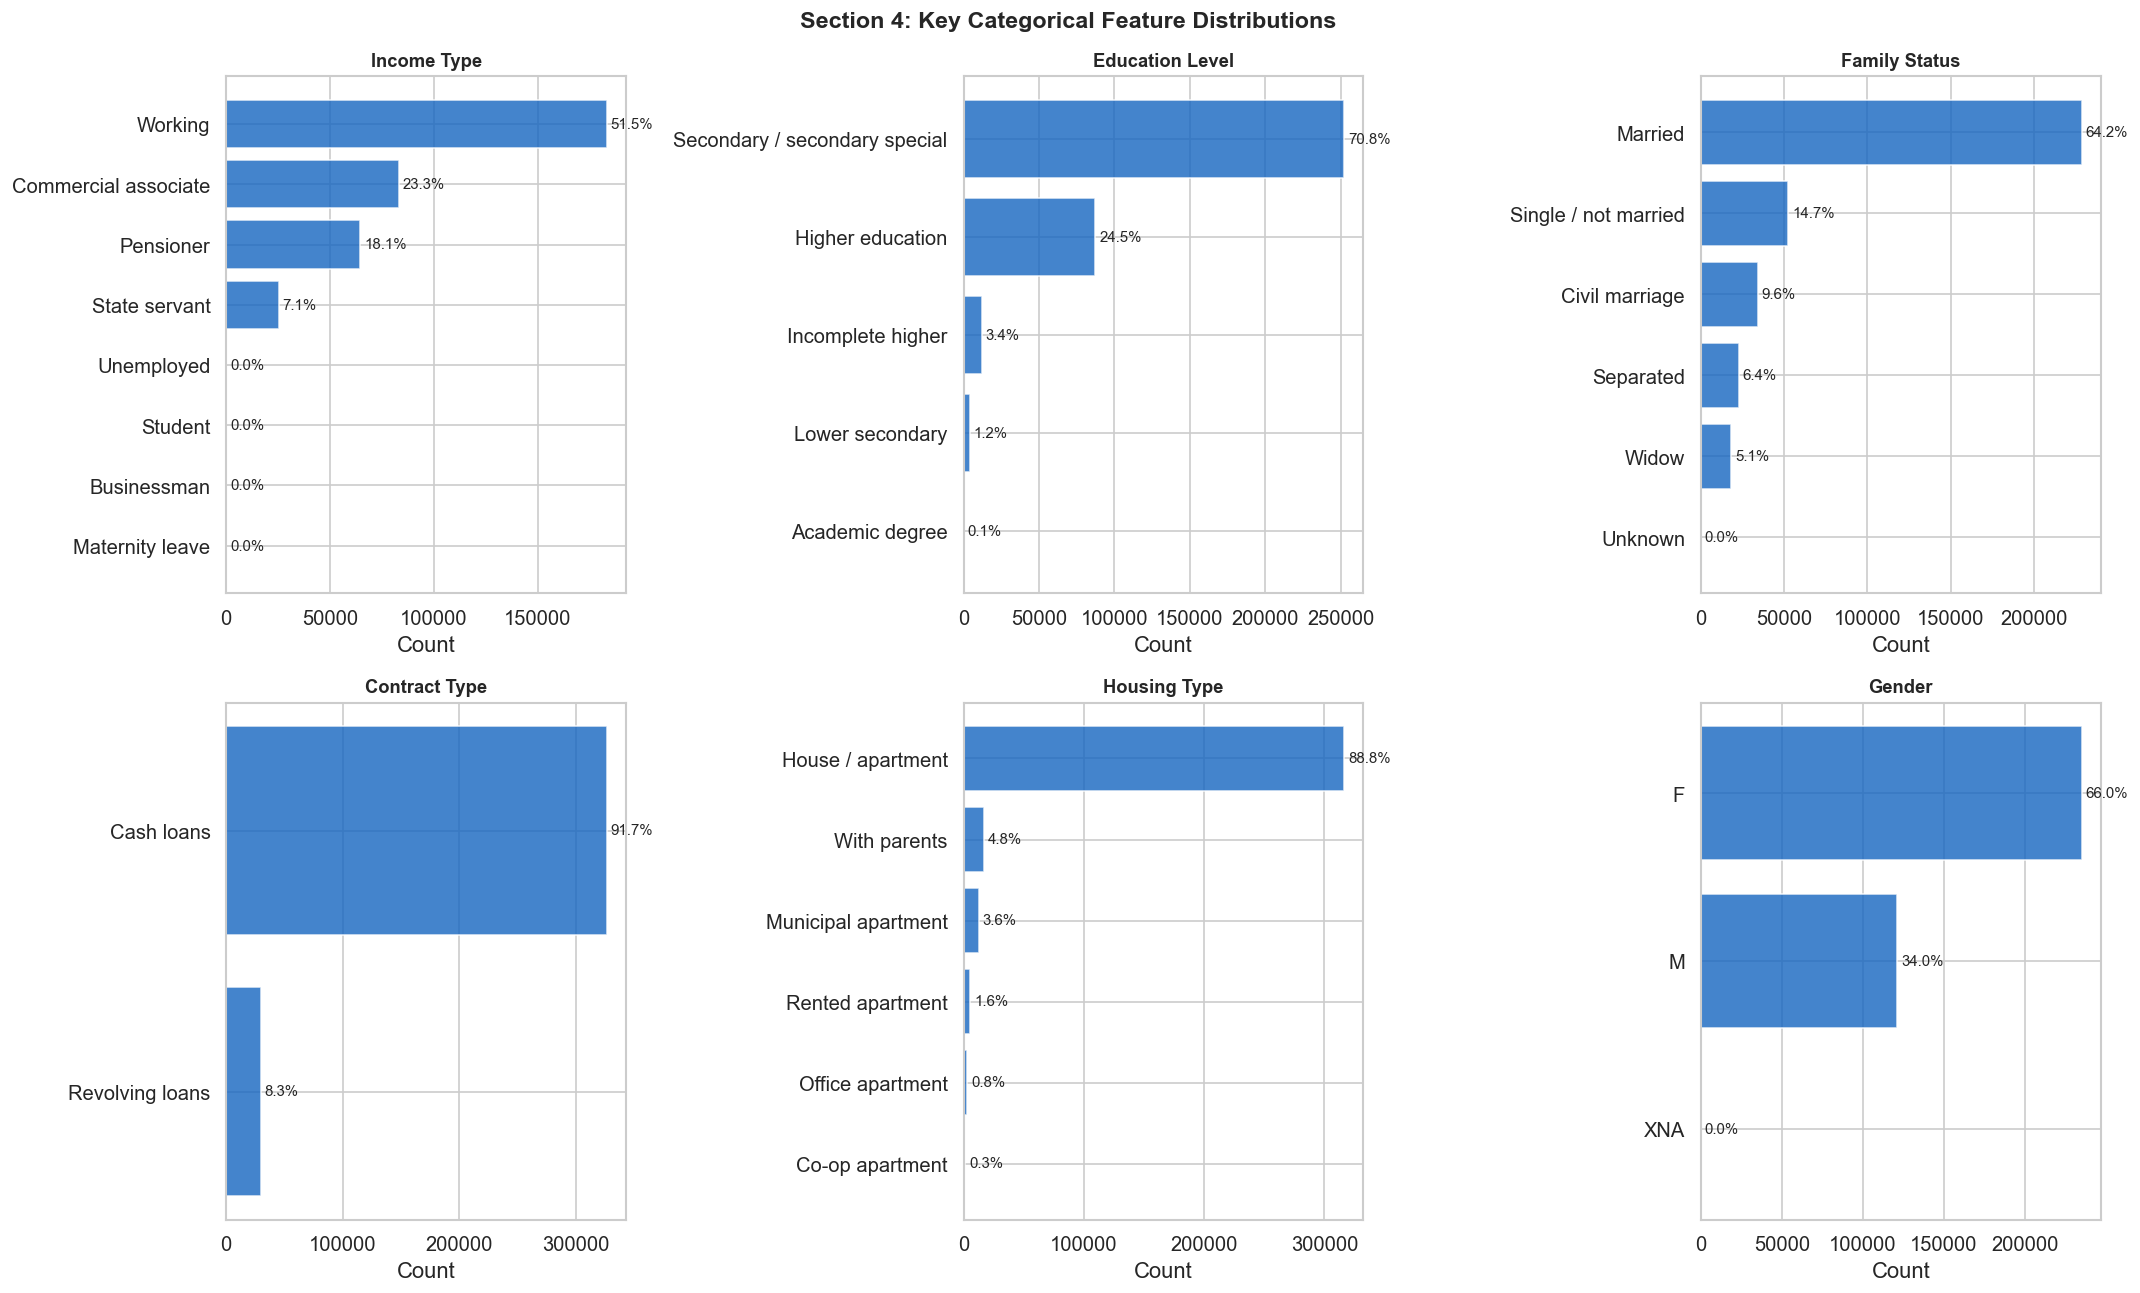


ORGANIZATION_TYPE: top 12 categories
ORGANIZATION_TYPE
Business Entity Type 3    78832
XNA                       64648
Self-employed             44332
Other                     19390
Medicine                  12909
Business Entity Type 2    12032
Government                11912
School                    10180
Trade: type 7              9134
Kindergarten               7918
Construction               7760
Business Entity Type 1     6871
Total unique: 58


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

plot_cols = [
    ('NAME_INCOME_TYPE', 'Income Type'),
    ('NAME_EDUCATION_TYPE', 'Education Level'),
    ('NAME_FAMILY_STATUS', 'Family Status'),
    ('NAME_CONTRACT_TYPE', 'Contract Type'),
    ('NAME_HOUSING_TYPE', 'Housing Type'),
    ('CODE_GENDER', 'Gender'),
]

for ax, (col, title) in zip(axes.flat, plot_cols):
    vc = app[col].value_counts(dropna=True).head(10)
    ax.barh(vc.index[::-1], vc.values[::-1], color='#1565C0', alpha=0.8)
    for i, (idx, val) in enumerate(vc.items()):
        ax.text(val + vc.max()*0.01, len(vc)-1-i, f'{val/len(app)*100:.1f}%', va='center', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Section 4: Key Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nORGANIZATION_TYPE: top 12 categories')
print(app['ORGANIZATION_TYPE'].value_counts().head(12).to_string())
print(f'Total unique: {app["ORGANIZATION_TYPE"].nunique()}')

### What we found

**`NAME_CONTRACT_TYPE`** is binary: Cash loans 90.5%, Revolving loans 9.5%. The lopsided split mirrors Home Credit's product mix. Encoded as a single 0/1.

**`CODE_GENDER`** is 65.8% female and 34.2% male, with 4 records coded `XNA`. We treat those 4 as missing. The field remains in the business view for descriptive fairness monitoring and is excluded from clustering, rules, and anomaly recommendations.

**`NAME_INCOME_TYPE`** is dominated by Working (51.6%), Commercial associate (23.3%), Pensioner (18.0%), and State servant (7.1%), which together cover 99.9% of rows. The remaining categories contain only 5 to 22 labeled rows each, far too few for stable outcome estimates. We combine them only to avoid unstable descriptive categories, then exclude income type from segmentation because it is a socioeconomic proxy.

**`NAME_EDUCATION_TYPE`** is concentrated in Secondary (71.0%) and Higher education (24.3%), with Lower secondary (1.2%) and Academic degree (0.1%) sparse. It can be stored as an ordinal field in the business artifact, but education is a socioeconomic proxy and does not shape the segments.

**`ORGANIZATION_TYPE`** has high cardinality (58 distinct values), and 18.0% are coded `XNA`, exactly matching the `DAYS_EMPLOYED` sentinel share. Those are the pensioners and unemployed for whom an employer does not apply. We first collapse the ~50 granular business-entity labels into about a dozen macro-sectors.

**Low-variance features** like `NAME_CONTRACT_TYPE` (90.5% one value), `NAME_HOUSING_TYPE` (88.7%), and `NAME_TYPE_SUITE` (80.8%) add little to distance-based separation and are candidates for exclusion.

**How categorical fields are stored.** One-hot encoding would create many sparse axes and let one source column outweigh a continuous measure in Euclidean distance. We therefore keep compact encodings in the business artifact, then apply a separate governance filter before building the clustering matrix:

- `NAME_EDUCATION_TYPE` is stored as ordinal 0-4 for readable analysis, but it is removed before clustering.
- `NAME_INCOME_TYPE` and `ORGANIZATION_TYPE` are frequency encoded for compact storage and profiling. Both are removed before clustering because category frequency can collapse unrelated groups onto the same coordinate and acts as a socioeconomic proxy.

---
## Section 5: Outliers, and what kind they are

### What we are checking, and why

Not all outliers are the same, and treating them the same is a mistake. In financial data they come in three flavours: impossible values that are simply wrong (age under 18, negative income), sentinel placeholders deliberately inserted to encode a state, and genuine extremes that are real but rare (a very high income). Each needs a different response.

We flag with IQR x 3 rather than the usual 1.5x, because financial distributions are naturally heavy-tailed and 1.5x would brand ordinary high earners as outliers. This section also sets up Phase 4: the three-way typology we define here is exactly how we will later sort the anomalies that phase finds.

                  column          IQR_lo         IQR_hi  n_outliers  pct_outliers       actual_max
        AMT_INCOME_TOTAL   -157,500.0000   472,500.0000        3588        1.0100 117,000,000.0000
              AMT_CREDIT -1,312,672.5000 2,380,230.0000         484        0.1400   4,050,000.0000
             AMT_ANNUITY    -37,957.5000    89,649.0000        1214        0.3400     258,025.5000
         AMT_GOODS_PRICE -1,089,000.0000 1,998,000.0000        1095        0.3100   4,050,000.0000
           DAYS_EMPLOYED    -10,460.0000     6,480.0000        4284        1.2000     365,243.0000
            CNT_CHILDREN         -3.0000         4.0000         148        0.0400          20.0000
         CNT_FAM_MEMBERS         -1.0000         6.0000         142        0.0400          21.0000
OBS_30_CNT_SOCIAL_CIRCLE         -6.0000         8.0000        7182        2.0200         354.0000
DEF_30_CNT_SOCIAL_CIRCLE          0.0000         0.0000       40686       11.4200          34.0000
OBS_60_CNT

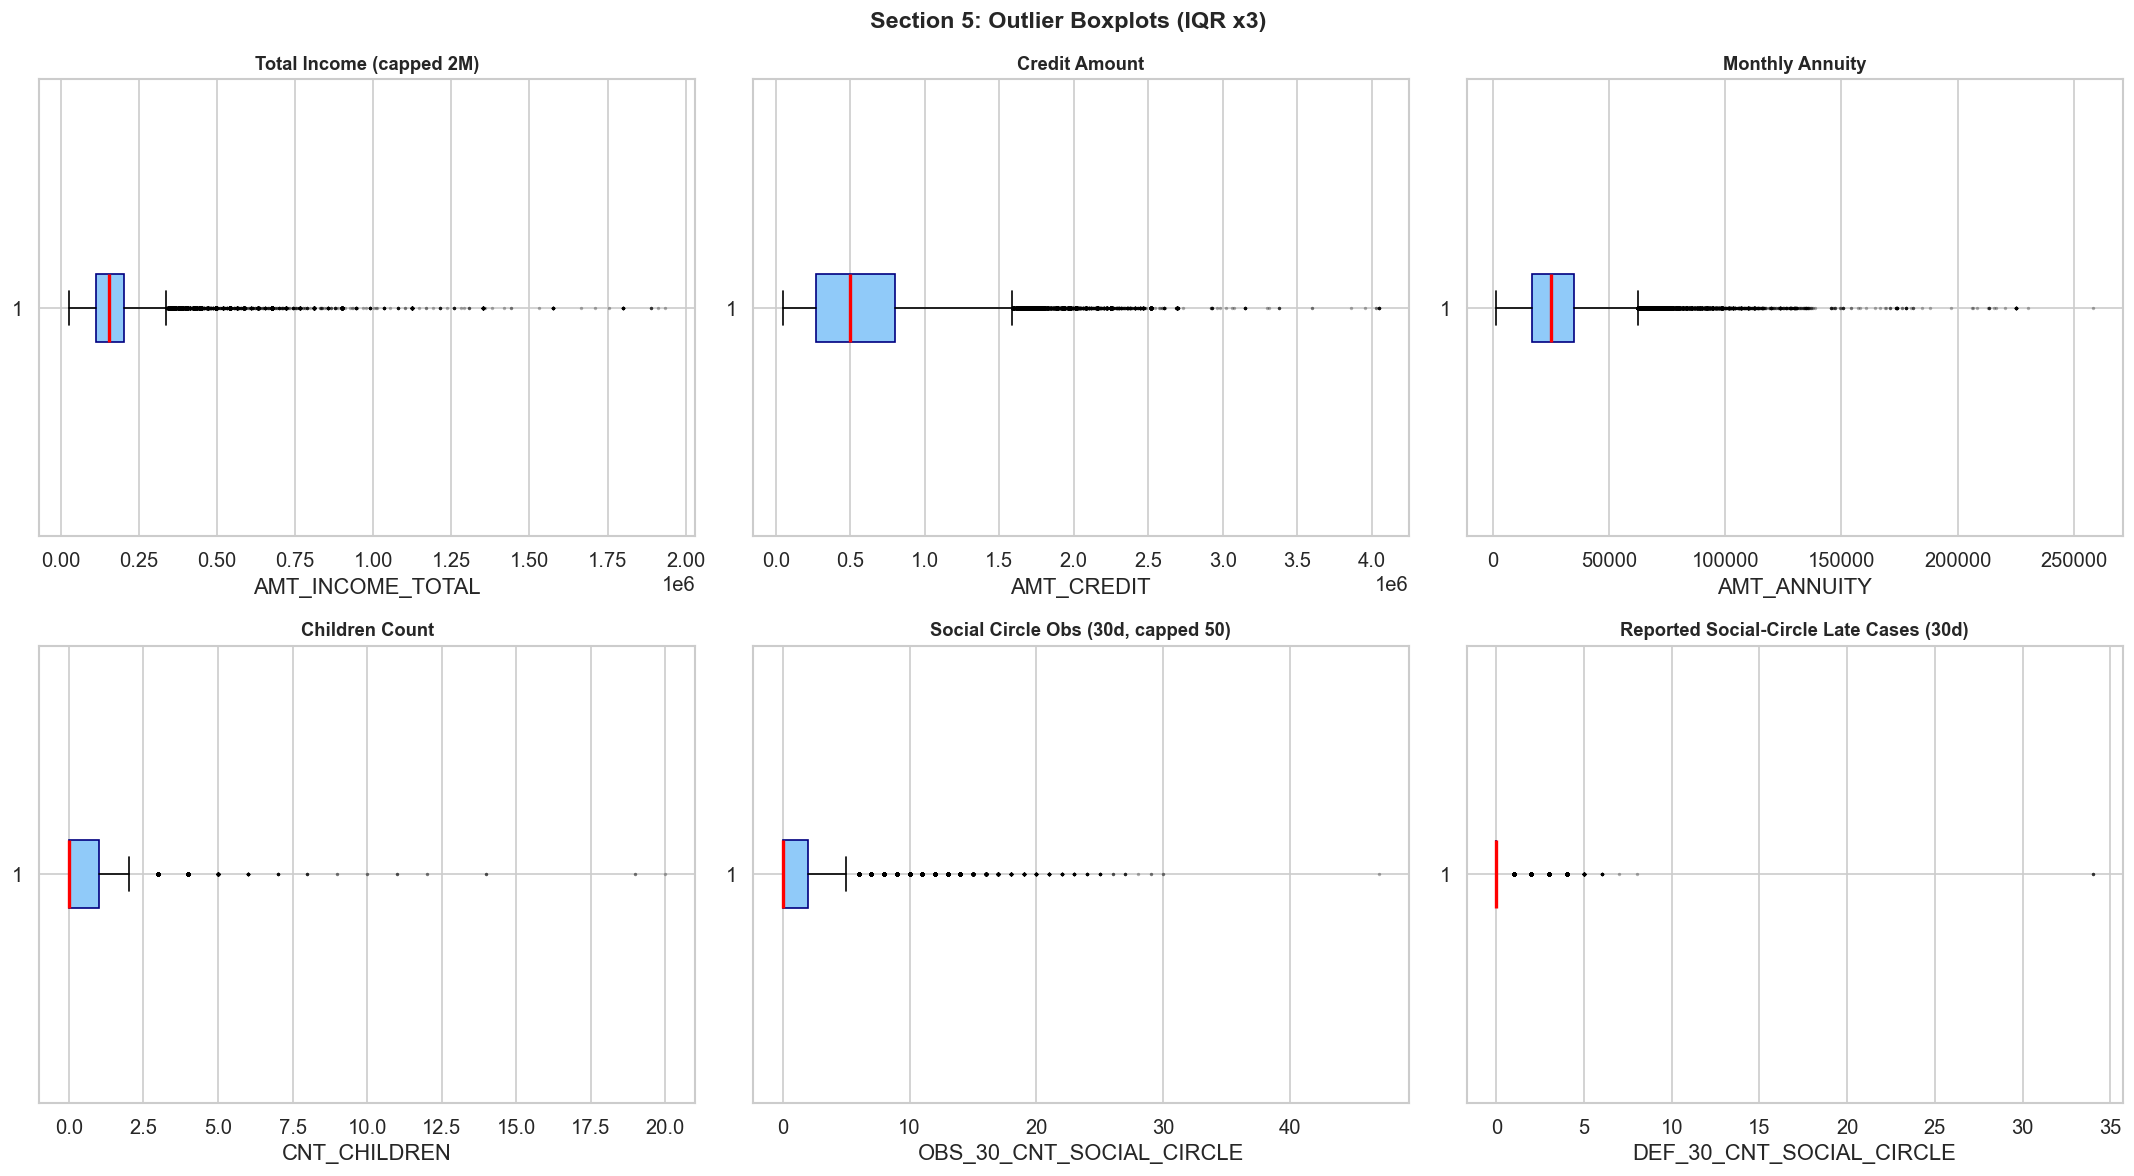


=== AMT_INCOME_TOTAL Extremes ===
p99: 486,000
max: 117,000,000
Records above 1M: 288


In [9]:
key_num = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE',
           'DAYS_EMPLOYED','CNT_CHILDREN','CNT_FAM_MEMBERS',
           'OBS_30_CNT_SOCIAL_CIRCLE','DEF_30_CNT_SOCIAL_CIRCLE',
           'OBS_60_CNT_SOCIAL_CIRCLE','DEF_60_CNT_SOCIAL_CIRCLE']

outlier_report = []
for col in key_num:
    if col not in app.columns: continue
    data = app[col].dropna()
    if col == 'DAYS_EMPLOYED': data = data[data != 365243]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
    n_out = ((app[col] < lo) | (app[col] > hi))
    if col == 'DAYS_EMPLOYED': n_out = n_out & (app[col] != 365243)
    n_out = n_out.sum()
    outlier_report.append({'column': col, 'IQR_lo': round(lo,1), 'IQR_hi': round(hi,1),
                           'n_outliers': n_out, 'pct_outliers': round(n_out/len(app)*100, 2),
                           'actual_max': app[col].max()})

out_df = pd.DataFrame(outlier_report)
print(out_df[['column','IQR_lo','IQR_hi','n_outliers','pct_outliers','actual_max']].to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
box_cols = [('AMT_INCOME_TOTAL',2e6,'Total Income (capped 2M)'),
            ('AMT_CREDIT',None,'Credit Amount'),
            ('AMT_ANNUITY',None,'Monthly Annuity'),
            ('CNT_CHILDREN',None,'Children Count'),
            ('OBS_30_CNT_SOCIAL_CIRCLE',50,'Social Circle Obs (30d, capped 50)'),
            ('DEF_30_CNT_SOCIAL_CIRCLE',None,'Reported Social-Circle Late Cases (30d)')]

for ax, (col, cap, title) in zip(axes.flat, box_cols):
    data = app[col].dropna()
    if col == 'DAYS_EMPLOYED': data = data[data != 365243]
    if cap: data = data[data <= cap]
    ax.boxplot(data, vert=False, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Section 5: Outlier Boxplots (IQR x3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== AMT_INCOME_TOTAL Extremes ===')
print(f'p99: {app["AMT_INCOME_TOTAL"].quantile(0.99):,.0f}')
print(f'max: {app["AMT_INCOME_TOTAL"].max():,.0f}')
print(f'Records above 1M: {(app["AMT_INCOME_TOTAL"] > 1e6).sum()}')

### What we found

**Sentinel value: `DAYS_EMPLOYED = 365,243` (18.0% of records).** The same placeholder from Section 3 is not a 1,000-year tenure. All 55,374 cases are pensioners or unemployed. We flag the placeholder, replace it with NaN, and retain the flag only to distinguish structural missingness from real tenure. Its near-perfect link with life stage is a proxy limitation that requires sensitivity and fairness testing before operational use.

**Genuine extremes: `AMT_INCOME_TOTAL` above currency units 1M (250 records).** These are not errors. The currency units 117M maximum is a true outlier, but the broader high-income group is an economically real segment, and deleting it would erase a meaningful population. We winsorize at the 99th percentile (currency units 472,500) and then log-transform, which tames the extreme without discarding anyone.

**Real but unsuitable for segmentation: `DEF_30_CNT_SOCIAL_CIRCLE` (11.4% non-zero).** The field is neither a data error nor an applicant repayment event. It describes people around the applicant and can act as a socioeconomic proxy. We retain a binned value only in the readable audit data and exclude it from clustering and anomaly detection.

**Large household counts need context, not an invented cap.** 126 records report more than four children, with a maximum of 19. The upper tail is rare, but rarity alone does not prove a capture error and the source documentation provides no correction rule. We leave the audit value unchanged and exclude children and family counts from the governed clustering axes because they are family-status proxies.

---
## Section 6: Feature Correlation Analysis

### What we are investigating and why

Correlation analysis serves two downstream purposes: **feature selection** (identifying redundant features so one of each pair can be removed from the mining matrix) and **feature interpretation** (understanding what each retained feature actually represents).

We compute the Pearson correlation matrix for all numerical features, then examine the strongest pairs. Correlation here is descriptive. It tells us which fields duplicate each other's information; it does not make a field causal or automatically suitable for clustering.


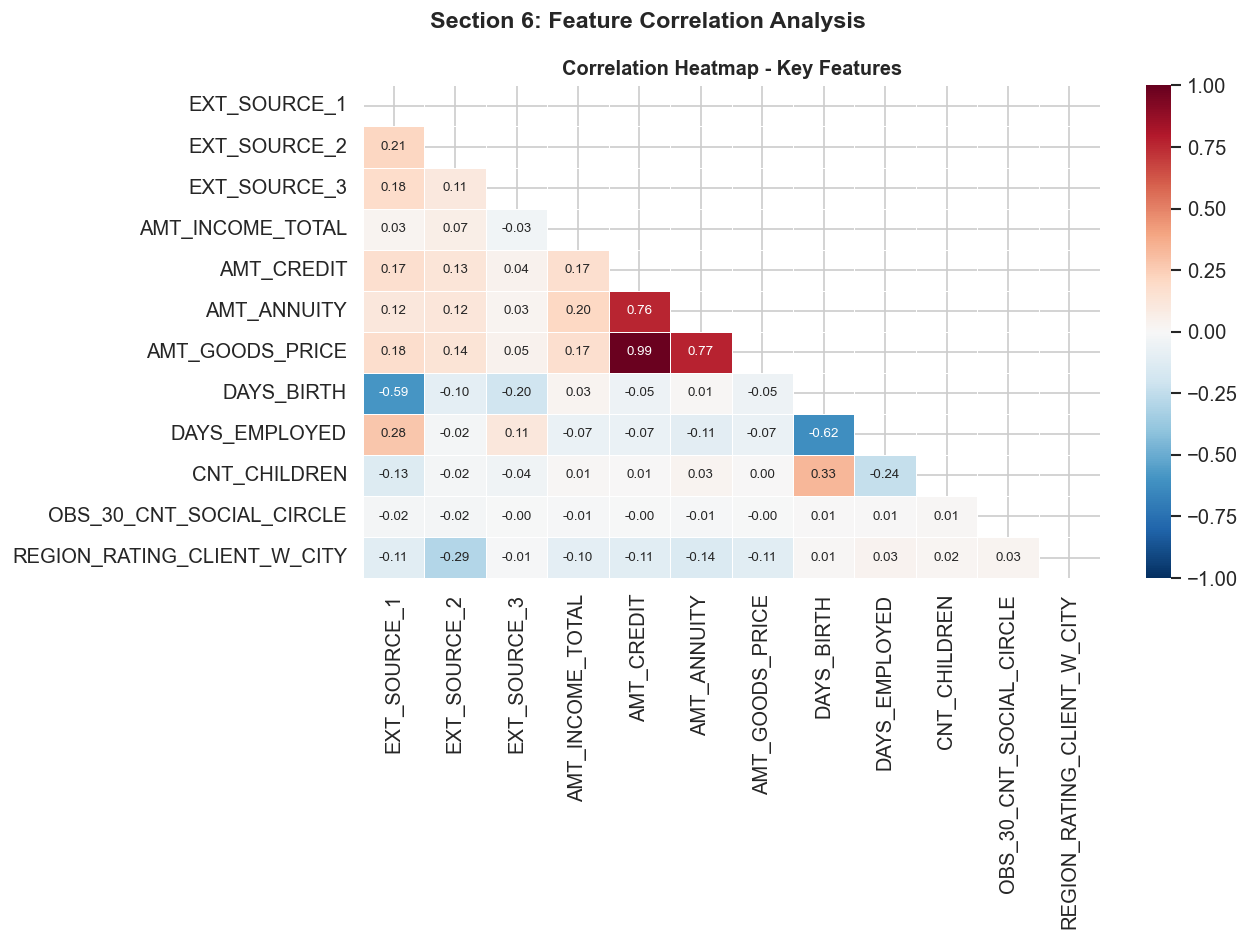

In [10]:
key_fields = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT_W_CITY',
]

fig, ax = plt.subplots(figsize=(11, 8))
corr_sub = app[key_fields].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Correlation Heatmap - Key Features', fontsize=12, fontweight='bold')
plt.suptitle('Section 6: Feature Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
print('=== Highly correlated feature pairs (|r| > 0.85) ===')
num_only = app.select_dtypes(include=np.number).columns.difference(['SK_ID_CURR'])
corr_matrix = app[num_only].corr()

high_corr_pairs = []
cols_list = corr_matrix.columns.tolist()
for i in range(len(cols_list)):
    for j in range(i+1, len(cols_list)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((cols_list[i], cols_list[j], r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'Total pairs with |r| > 0.85: {len(high_corr_pairs)}')
print('\nTop 20:')
for c1, c2, r in high_corr_pairs[:20]:
    print(f'  {c1:<40} vs  {c2:<35}  r={r:.3f}')

=== Highly correlated feature pairs (|r| > 0.85) ===


Total pairs with |r| > 0.85: 89

Top 20:
  DAYS_EMPLOYED                            vs  FLAG_EMP_PHONE                       r=-1.000
  OBS_30_CNT_SOCIAL_CIRCLE                 vs  OBS_60_CNT_SOCIAL_CIRCLE             r=0.999
  YEARS_BUILD_AVG                          vs  YEARS_BUILD_MEDI                     r=0.999
  FLOORSMIN_AVG                            vs  FLOORSMIN_MEDI                       r=0.997
  FLOORSMAX_AVG                            vs  FLOORSMAX_MEDI                       r=0.997
  ENTRANCES_AVG                            vs  ENTRANCES_MEDI                       r=0.997
  ELEVATORS_AVG                            vs  ELEVATORS_MEDI                       r=0.996
  COMMONAREA_AVG                           vs  COMMONAREA_MEDI                      r=0.996
  LIVINGAREA_AVG                           vs  LIVINGAREA_MEDI                      r=0.995
  APARTMENTS_AVG                           vs  APARTMENTS_MEDI                      r=0.995
  LIVINGAPARTMENTS_AVG                

### What we found

**89 highly correlated pairs (|r| > 0.85),** almost all of them one of three kinds of redundancy. First, the `_AVG`/`_MODE`/`_MEDI` triplication at r ~ 0.99: every building measurement exists three times, and keeping all three would triple its weight in distance, so we keep `_MODE` and drop the other two. Second, `DAYS_EMPLOYED` versus `FLAG_EMP_PHONE` (whether a work phone was provided) at r = -1.0, perfectly redundant once the employment sentinel is handled, so `FLAG_EMP_PHONE` goes. Third, `OBS_30` versus `OBS_60` (the number of people observed around the applicant over two windows) at r = 0.998, the same social-network count twice, so we keep the 30-day one.

**The three external scores have limited pairwise linear overlap** (r = 0.11 to 0.21), so all three values stay. The source does not disclose what each score represents, and low correlation alone does not prove independence.

**Age and the first external score move together (r = 0.59).** The dataset does not document the score formula, so we cannot claim that age causes the relationship or that the score measures accumulated history. The correlation is a governance warning: age must remain outside the clustering and decision logic, while the relationship is monitored for possible proxy effects.

Several `FLAG_DOCUMENT_*` fields (indicators for individual documents supplied with the application) sit near zero correlation with the other variables; any value they add would need to appear through interactions rather than a simple linear relationship.


---
## Section 7: The five history tables

### What we are checking, and why

The application table describes the moment of application. The five history tables describe behaviour over time: external bureau records, previous applications with their outcomes, POS and cash-loan monthly snapshots, instalment payments, and revolving card balances. Each table has many rows per applicant, so each must be summarized to the applicant level before it can join the analysis.

This section checks what each source actually contains, how deep the histories run, and which summaries preserve the business meaning: history depth, repayment timing, refusal outcomes, and revolving usage intensity.


In [12]:
print('=== BUREAU: External Credit History ===')
bureau_counts = bureau.groupby('SK_ID_CURR').size()
n_app = app['SK_ID_CURR'].nunique()
print(f'Applicants with bureau records : {bureau_counts.shape[0]:,} ({bureau_counts.shape[0]/n_app*100:.1f}%)')
print(f'Applicants WITHOUT bureau      : {n_app - bureau_counts.shape[0]:,} ({(n_app-bureau_counts.shape[0])/n_app*100:.1f}%)')
print(f'Records per applicant: p25={bureau_counts.quantile(0.25):.0f}  p50={bureau_counts.quantile(0.5):.0f}  p75={bureau_counts.quantile(0.75):.0f}  p95={bureau_counts.quantile(0.95):.0f}  max={bureau_counts.max()}')
print('\nCredit active status:')
print(bureau['CREDIT_ACTIVE'].value_counts().to_string())

print('\n=== PREVIOUS APPLICATION ===')
prev_counts = prev.groupby('SK_ID_CURR').size()
print(f'Records: {len(prev):,}  |  Unique applicants: {prev_counts.shape[0]:,}')
print(f'Apps per applicant: p50={prev_counts.median():.0f}  p95={prev_counts.quantile(0.95):.0f}')
print('Contract status:')
print(prev['NAME_CONTRACT_STATUS'].value_counts().to_string())
print(f'Historical approval rate: {(prev["NAME_CONTRACT_STATUS"]=="Approved").mean()*100:.1f}%')

print('\n=== INSTALLMENT PAYMENTS ===')
inst_copy = inst.copy()
inst_copy['DPD'] = (inst_copy['DAYS_ENTRY_PAYMENT'] - inst_copy['DAYS_INSTALMENT']).clip(lower=0)
print(f'Records: {len(inst):,}  |  Unique applicants: {inst["SK_ID_CURR"].nunique():,}')
print(f'Mean DPD: {inst_copy["DPD"].mean():.2f} days')
print(f'Late payments (DPD>0): {(inst_copy["DPD"]>0).mean()*100:.1f}%')
print(f'Severe late (DPD>30): {(inst_copy["DPD"]>30).mean()*100:.2f}%')

print('\n=== CREDIT CARD BALANCE ===')
cc_months = cc.groupby('SK_ID_CURR')['MONTHS_BALANCE'].nunique()
util = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
print(f'Records: {len(cc):,}  |  Unique applicants: {cc["SK_ID_CURR"].nunique():,}')
print(f'Months of history: p50={cc_months.median():.0f}  p95={cc_months.quantile(0.95):.0f}')
print(f'Mean utilization: {util.mean()*100:.1f}%  |  median: {util.median()*100:.1f}%')

print('\n=== BUREAU BALANCE ===')
bb_months = bureau_bal.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].nunique()
print(f'Records: {len(bureau_bal):,}')
print(f'Observation window: {bureau_bal["MONTHS_BALANCE"].min()} to {bureau_bal["MONTHS_BALANCE"].max()} months')
print(f'History per bureau record: p50={bb_months.median():.0f}  p95={bb_months.quantile(0.95):.0f}')
print('\nMonthly status distribution:')
print(bureau_bal['STATUS'].value_counts().to_string())

=== BUREAU: External Credit History ===


Applicants with bureau records : 305,811 (85.8%)
Applicants WITHOUT bureau      : 50,444 (14.2%)
Records per applicant: p25=2  p50=4  p75=8  p95=14  max=116

Credit active status:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21

=== PREVIOUS APPLICATION ===


Records: 1,670,214  |  Unique applicants: 338,857
Apps per applicant: p50=4  p95=13
Contract status:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436


Historical approval rate: 62.1%

=== INSTALLMENT PAYMENTS ===


Records: 13,605,401  |  Unique applicants: 339,587
Mean DPD: 1.03 days
Late payments (DPD>0): 8.4%


Severe late (DPD>30): 0.28%

=== CREDIT CARD BALANCE ===


Records: 3,840,312  |  Unique applicants: 103,558
Months of history: p50=22  p95=96


Mean utilization: 37.5%  |  median: 1.1%

=== BUREAU BALANCE ===


Records: 27,299,925
Observation window: -96 to 0 months
History per bureau record: p50=26  p95=90

Monthly status distribution:


STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847


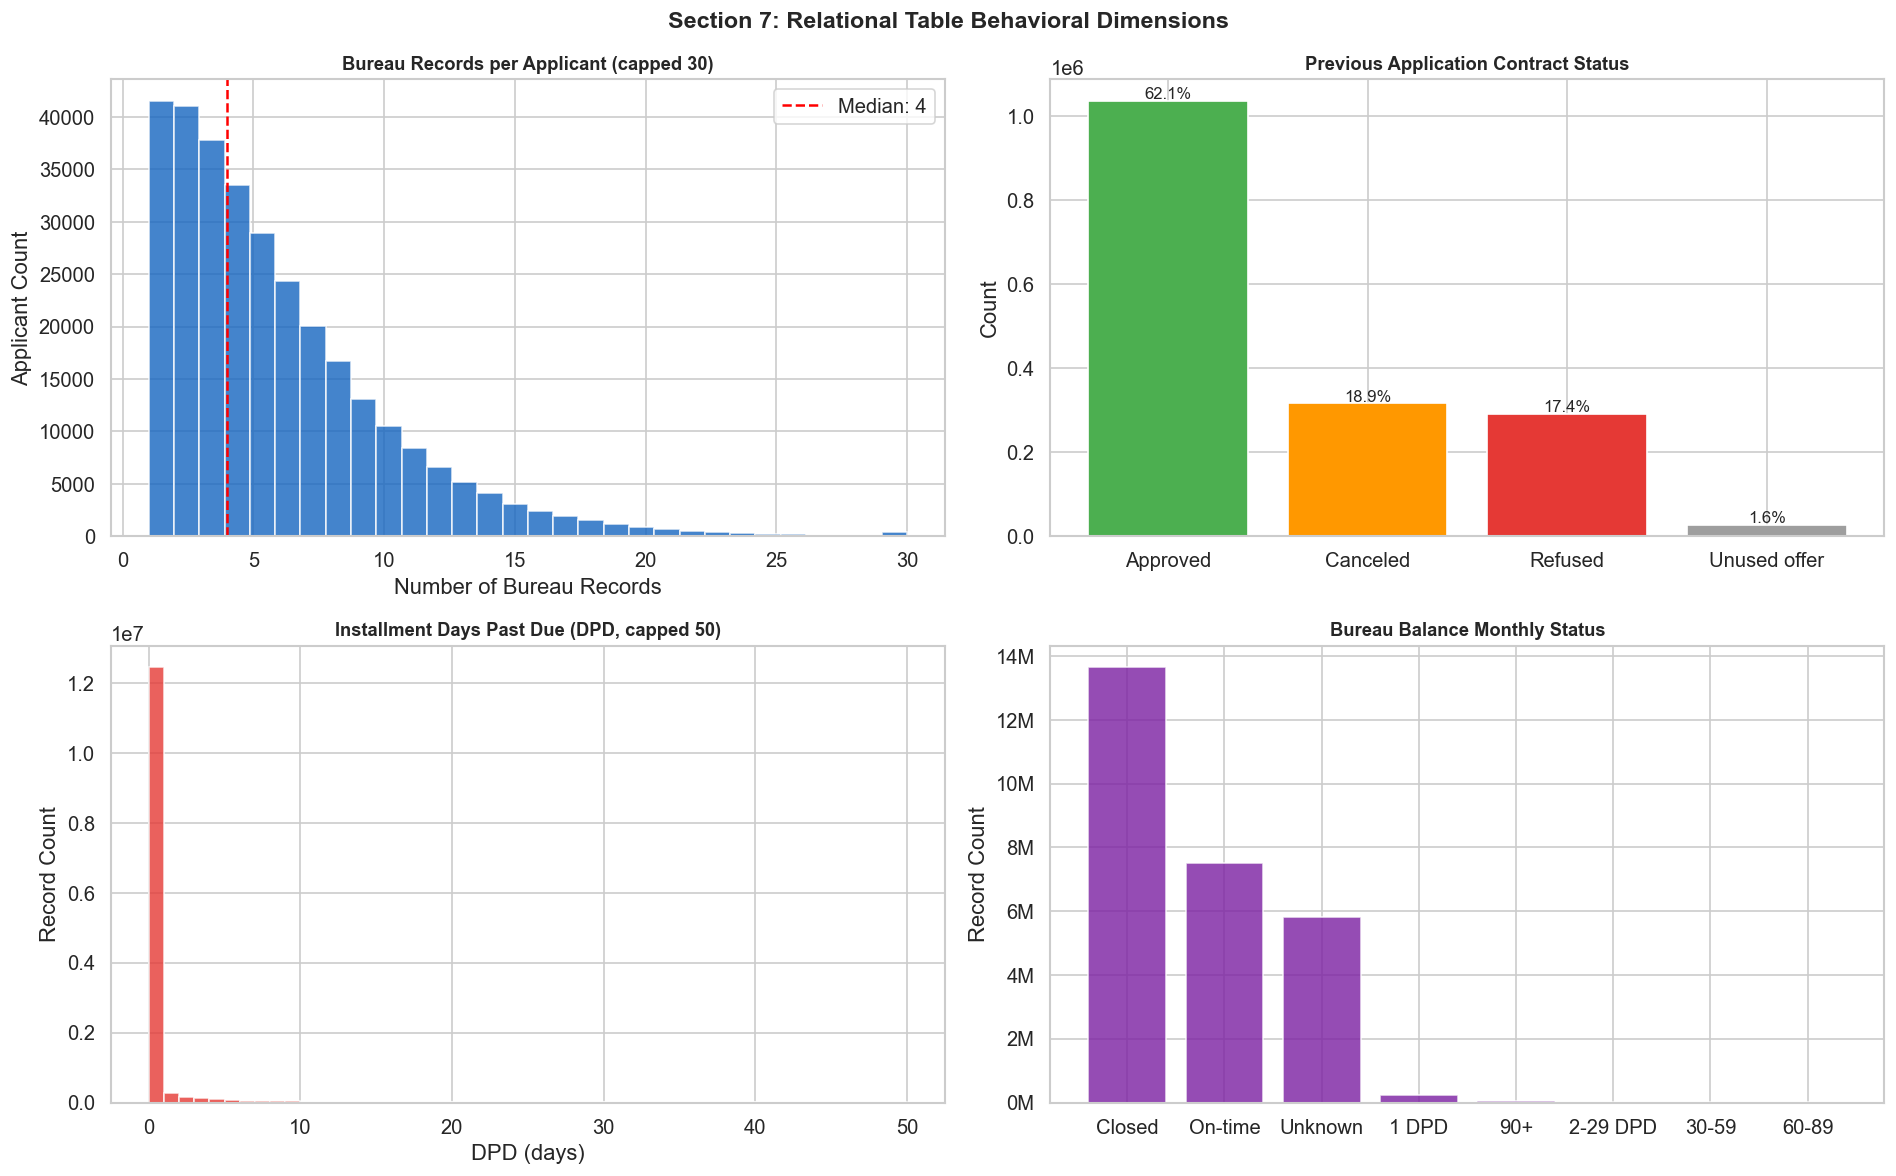

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(bureau_counts.clip(upper=30), bins=30, color='#1565C0', alpha=0.8, edgecolor='white')
ax.set_title('Bureau Records per Applicant (capped 30)', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of Bureau Records')
ax.set_ylabel('Applicant Count')
ax.axvline(bureau_counts.median(), color='red', linestyle='--', label=f'Median: {bureau_counts.median():.0f}')
ax.legend()

ax = axes[0, 1]
prev_status = prev['NAME_CONTRACT_STATUS'].value_counts()
ax.bar(prev_status.index, prev_status.values, color=['#4CAF50','#FF9800','#E53935','#9E9E9E'])
ax.set_title('Previous Application Contract Status', fontsize=11, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, prev_status.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f'{val/len(prev)*100:.1f}%', ha='center', fontsize=10)

ax = axes[1, 0]
inst_copy2 = inst.copy()
inst_copy2['DPD'] = (inst_copy2['DAYS_ENTRY_PAYMENT'] - inst_copy2['DAYS_INSTALMENT']).clip(lower=0)
ax.hist(inst_copy2['DPD'].clip(upper=50), bins=50, color='#E53935', alpha=0.8, edgecolor='white')
ax.set_title('Installment Days Past Due (DPD, capped 50)', fontsize=11, fontweight='bold')
ax.set_xlabel('DPD (days)')
ax.set_ylabel('Record Count')

ax = axes[1, 1]
status_map = {'C':'Closed','0':'On-time','1':'1 DPD','2':'2-29 DPD','3':'30-59','4':'60-89','5':'90+','X':'Unknown'}
bb_status = bureau_bal['STATUS'].map(status_map).fillna(bureau_bal['STATUS']).value_counts()
ax.bar(bb_status.index, bb_status.values, color='#7B1FA2', alpha=0.8)
ax.set_title('Bureau Balance Monthly Status', fontsize=11, fontweight='bold')
ax.set_ylabel('Record Count')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Section 7: Relational Table Behavioral Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What we found

**Bureau depth.** In the combined analytical table, 305,811 applications have at least one joined bureau record and 50,444 (14.16%) do not. Among matched histories the median is 4 records (p75 = 8, p95 = 14, max = 116). About 63% of recorded bureau credits are closed and 37% active. These are historical source aggregates; an active-to-closed ratio is a review prompt, not proof of the applicant's current debt position.

**Repayment quality from bureau balance.** This table covers 96 months (8 years). Its STATUS field codes C = closed, 0 = on-time, X = unknown, and 1 to 5 for worsening days-past-due. Closed (13.6M) and on-time (7.5M) records dominate, so histories are mostly healthy, but 242,347 records with 1+ DPD and 62,406 with 90+ DPD are real delinquency signals.

**Past applications describe earlier Home Credit decisions.** 61.9% of previous applications were approved and 17.4% were refused. Those statuses reflect the evidence and policy used at the time; they are useful for reconciling historical decisions, but they are not independent proof of the applicant's current risk. A median of four prior applications shows substantial earlier engagement with Home Credit.

**Observed instalment timing.** 8.4% of historical instalments were paid late (DPD > 0), with a mean of 1.03 days and a maximum of 2,884, so the tail is long. A large historical delay is a review signal, but this aggregate does not establish current arrears, cure status, or legal default. Those facts need source-level verification.

**Historical revolving-credit use.** Mean and maximum balance-to-limit ratios, recorded balances, and months of history summarise prior card use. High historical utilisation can prompt an affordability review, but the data does not establish a rising trend or the applicant's current balance. Current status must be verified before any action.

**Absence measures evidence availability.** `FLAG_NO_BUREAU` marks the 50,444 combined applications with no joined bureau record. It preserves a source-coverage distinction without claiming that the applicant has a thin file or worse repayment behaviour.

---
## Section 8: How features relate to each other

### What we are checking, and why

Single-feature distributions describe variables in isolation. But the clusters in Phase 2 will be defined by *combinations*, so understanding those combinations now means we can later explain a cluster precisely instead of hand-waving. We look at six pairs, each picked for a domain reason, and compare what we expected against what the data shows.

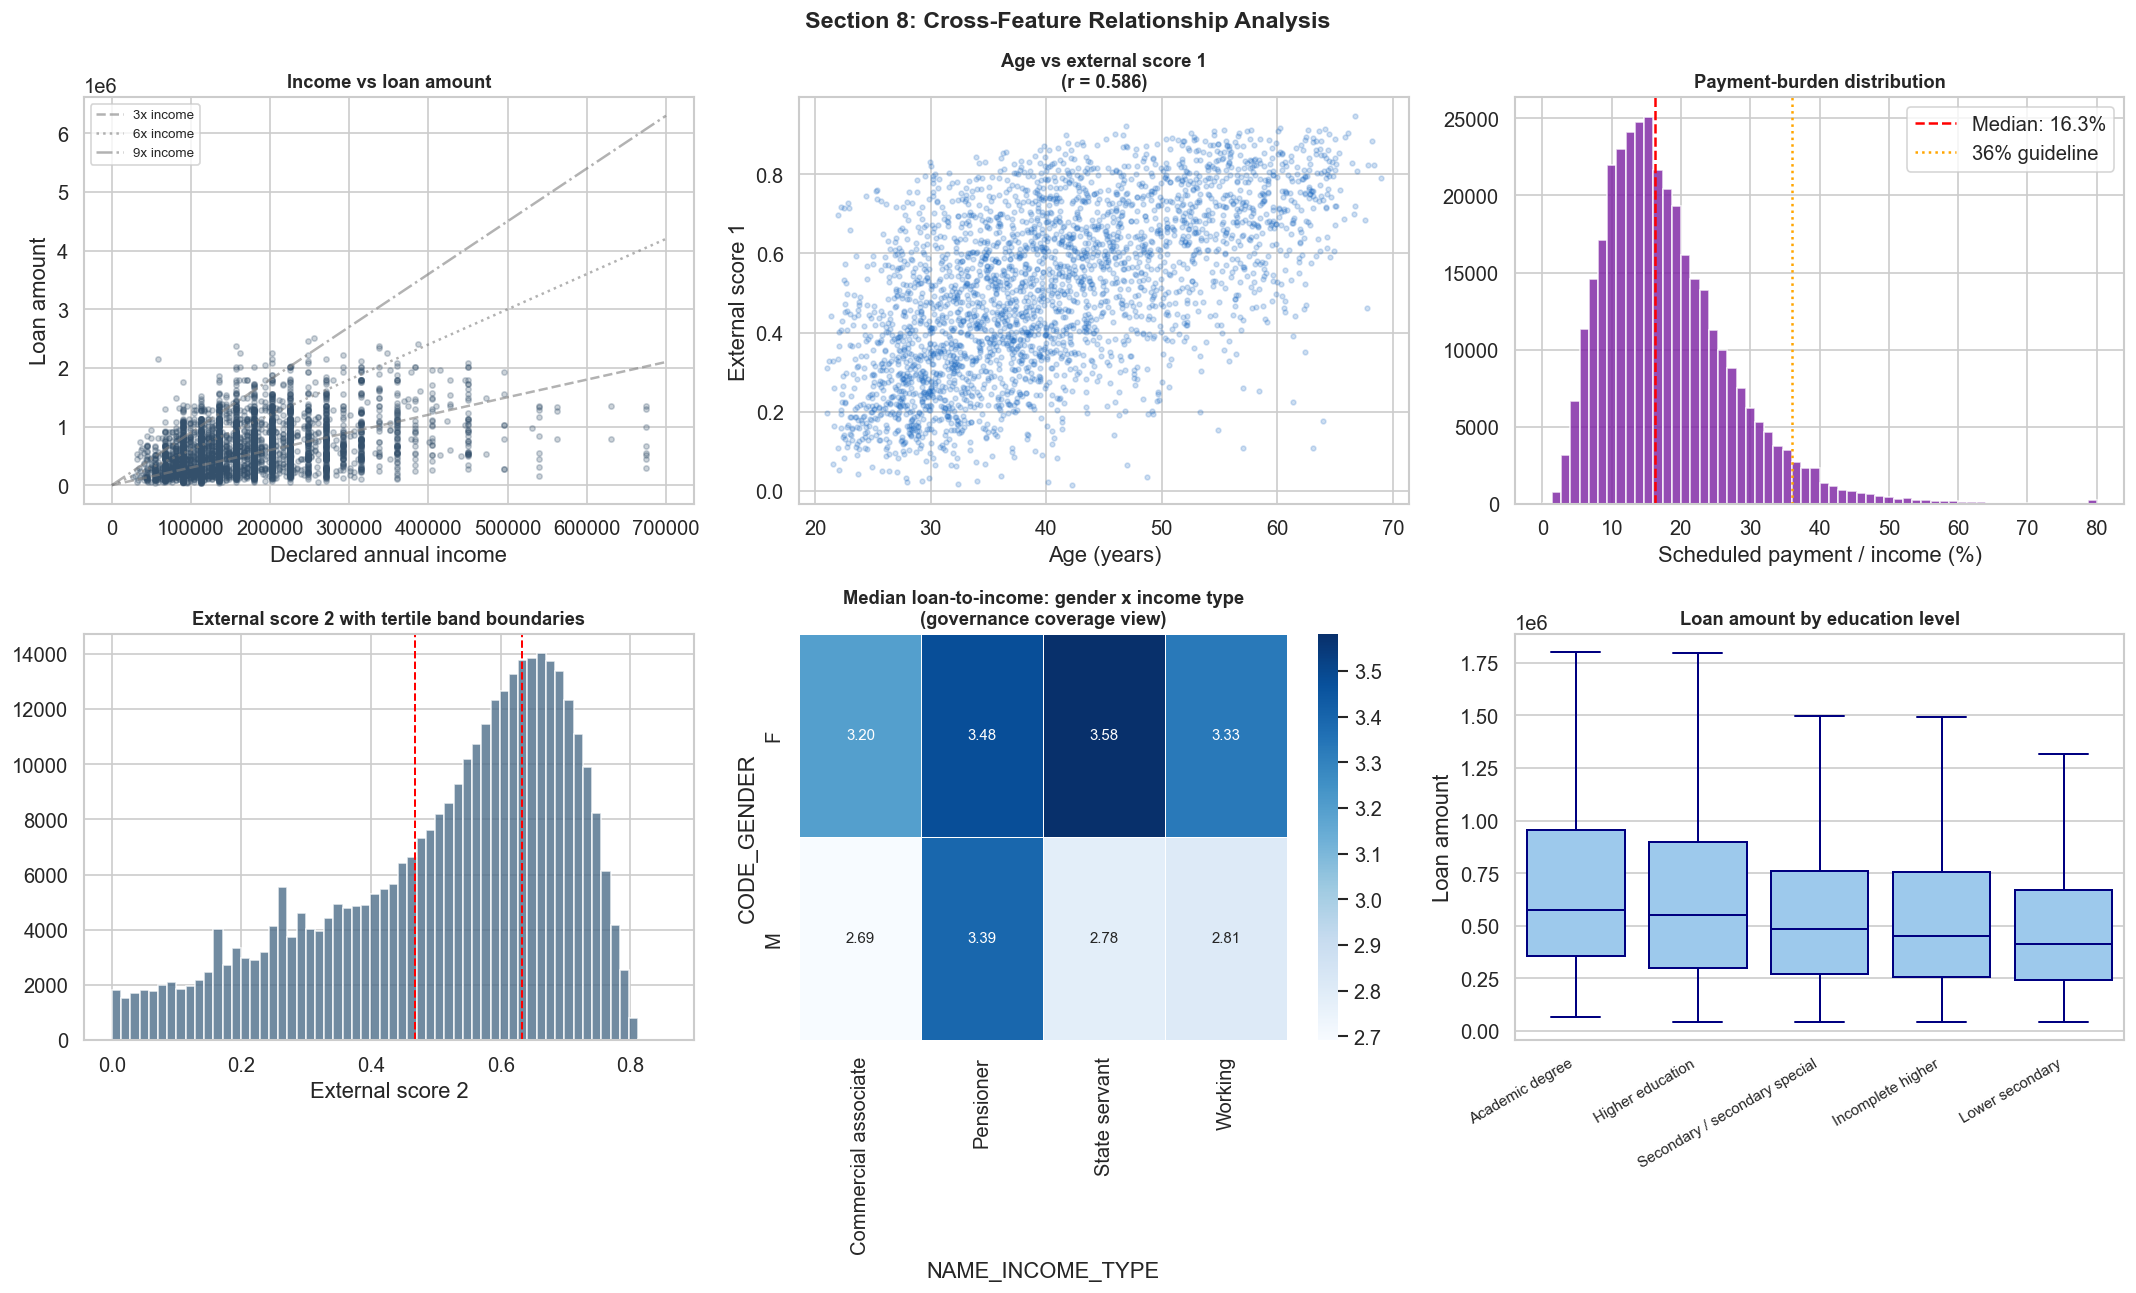

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Income vs loan amount with leverage guide lines
ax = axes[0, 0]
sample = app[app['AMT_INCOME_TOTAL'] < 700000].sample(5000, random_state=42)
ax.scatter(sample['AMT_INCOME_TOTAL'], sample['AMT_CREDIT'],
           alpha=0.25, s=10, color='#34506B')
ax.set_xlabel('Declared annual income')
ax.set_ylabel('Loan amount')
ax.set_title('Income vs loan amount', fontsize=11, fontweight='bold')
x_r = np.linspace(0, 700000, 100)
for ratio, ls in [(3, '--'), (6, ':'), (9, '-.')]:
    ax.plot(x_r, x_r * ratio, ls, color='gray', alpha=0.6, label=f'{ratio}x income')
ax.legend(fontsize=8)

# 2. Age vs first external score
ax = axes[0, 1]
s2 = app[['DAYS_BIRTH', 'EXT_SOURCE_1']].dropna().sample(3000, random_state=42)
s2 = s2.copy()
s2['age'] = s2['DAYS_BIRTH'].abs() / 365.25
ax.scatter(s2['age'], s2['EXT_SOURCE_1'], alpha=0.2, s=8, color='#1565C0')
r = s2[['age', 'EXT_SOURCE_1']].corr().iloc[0, 1]
ax.set_xlabel('Age (years)')
ax.set_ylabel('External score 1')
ax.set_title(f'Age vs external score 1\n(r = {r:.3f})', fontsize=11, fontweight='bold')

# 3. Scheduled-payment burden distribution
ax = axes[0, 2]
dti = (app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'] * 100).clip(upper=80)
ax.hist(dti, bins=60, color='#7B1FA2', alpha=0.8, edgecolor='white')
ax.axvline(dti.median(), color='red', linestyle='--', label=f'Median: {dti.median():.1f}%')
ax.axvline(36, color='orange', linestyle=':', label='36% guideline')
ax.set_xlabel('Scheduled payment / income (%)')
ax.set_title('Payment-burden distribution', fontsize=11, fontweight='bold')
ax.legend()

# 4. External score 2 distribution with the Phase 3 band boundaries
ax = axes[1, 0]
ext2 = app['EXT_SOURCE_2'].dropna()
tertiles = ext2.quantile([1/3, 2/3])
ax.hist(ext2, bins=60, color='#4E6E8A', alpha=0.8, edgecolor='white')
for q in tertiles:
    ax.axvline(q, color='red', linestyle='--', linewidth=1.2)
ax.set_xlabel('External score 2')
ax.set_title('External score 2 with tertile band boundaries', fontsize=11, fontweight='bold')

# 5. Leverage by gender and income type: governance view, no outcome involved
ax = axes[1, 1]
gov = app[app['CODE_GENDER'] != 'XNA'].copy()
gov['cti'] = gov['AMT_CREDIT'] / gov['AMT_INCOME_TOTAL']
pivot = gov.groupby(['CODE_GENDER', 'NAME_INCOME_TYPE'])['cti'].median().unstack()
valid_inc = app['NAME_INCOME_TYPE'].value_counts()
pivot = pivot[[c for c in pivot.columns if valid_inc.get(c, 0) > 100]]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Median loan-to-income: gender x income type\n(governance coverage view)',
             fontsize=11, fontweight='bold')

# 6. Loan amount by education
ax = axes[1, 2]
edu_order = app.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=app, x='NAME_EDUCATION_TYPE', y='AMT_CREDIT',
            order=edu_order, ax=ax, showfliers=False,
            color='#90CAF9', linecolor='navy', linewidth=1.2)
ax.set_xlabel('')
ax.set_ylabel('Loan amount')
ax.set_title('Loan amount by education level', fontsize=11, fontweight='bold')
ax.set_xticklabels(edu_order, rotation=30, ha='right', fontsize=9)
plt.suptitle('Section 8: Cross-Feature Relationship Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
print('=== Credit-to-Income Ratio ===')
cti = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
print(f'Median: {cti.median():.2f}x')
print(f'p75   : {cti.quantile(0.75):.2f}x')
print(f'p95   : {cti.quantile(0.95):.2f}x')
print(f'>6x   : {(cti>6).sum():,} ({(cti>6).mean()*100:.1f}%)')

print('\n=== Age vs EXT_SOURCE correlations ===')
app['age_years'] = app['DAYS_BIRTH'].abs() / 365.25
for src in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
    r = app[['age_years',src]].dropna().corr().iloc[0,1]
    print(f'  Age vs {src}: r = {r:.3f}')

print('\n=== Debt-to-Income (Annuity/Income) ===')
dti2 = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
print(f'Median DTI: {dti2.median()*100:.1f}%')
print(f'p75 DTI   : {dti2.quantile(0.75)*100:.1f}%')
print(f'p95 DTI   : {dti2.quantile(0.95)*100:.1f}%')
print(f'DTI > 50% : {(dti2>0.5).sum():,} ({(dti2>0.5).mean()*100:.2f}%)')

print('\n=== AMT_CREDIT median by education ===')
print(app.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].median().sort_values(ascending=False).to_string())

=== Credit-to-Income Ratio ===
Median: 3.16x
p75   : 5.00x
p95   : 8.95x
>6x   : 59,080 (16.6%)

=== Age vs EXT_SOURCE correlations ===
  Age vs EXT_SOURCE_1: r = 0.587
  Age vs EXT_SOURCE_2: r = 0.095
  Age vs EXT_SOURCE_3: r = 0.202

=== Debt-to-Income (Annuity/Income) ===
Median DTI: 16.3%
p75 DTI   : 22.9%
p95 DTI   : 35.5%
DTI > 50% : 2,958 (0.83%)

=== AMT_CREDIT median by education ===
NAME_EDUCATION_TYPE
Academic degree                 576,000.0000
Higher education                550,980.0000
Secondary / secondary special   485,640.0000
Incomplete higher               452,385.0000
Lower secondary                 414,792.0000


### What we found

**1. The loan amount must be read against income.** The median loan-to-income ratio is 3.16x, the p95 is 8.95x, and 10,424 applications (2.9%) exceed 10 times declared annual income. A multi-year loan can naturally exceed one year of income, so the ratio is not a failure label. Its value is comparative: the same loan amount implies a different burden at a different income level.

**2. Age and the first external score move together (r = 0.59).** The dataset does not document the score formula, so we cannot claim that age causes the relationship or that the score measures accumulated history. The correlation is a governance warning: age must remain outside the clustering and decision logic, while the relationship is monitored for possible proxy effects.

**3. The scheduled-payment burden is concentrated below 35.5%.** The median payment-to-income ratio is 16.3%, the p95 is 35.5%, and 2,958 applicants (0.8%) exceed 50%. This ratio omits living costs, other obligations, household resources, and loan timing. It supports triage for an affordability review, not a conclusion about how comfortable the portfolio is.

**4. Leverage differs across demographic groups.** The gender-by-income-type view of median loan-to-income is a fairness-monitoring coverage check, not evidence that any group borrows recklessly. Small cells and product mix confound any comparison, and neither field forms clusters or recommendations.

**5. The loan amount differs by education category.** The median is highest for academic-degree holders and lowest for the lower-secondary group. Education is a socioeconomic proxy, so this unadjusted difference is used only as a fairness and coverage check; it is excluded from segmentation and decision logic.


---
## Section 9: Summary and the handoff to preprocessing

### What this section does

This is the formal bridge from understanding (Step 1) to action (Step 2). Every finding above is mapped to one concrete preprocessing decision, so the pipeline executes what is written here and nothing it does should be a surprise.

---

## Key findings and what they imply

### Issues that must be fixed first

1. **The `DAYS_EMPLOYED` sentinel (365,243)** touches 18.1% of rows. It has to be flagged and separated before any numeric treatment, because feeding a 1,000-year tenure into a distance calculation corrupts it.
2. **Extreme `AMT_INCOME_TOTAL` values:** one record at currency units 117M and 288 above currency units 1M would dominate distances uncapped, so a log transform (after a p99 cap) is mandatory.
3. **Housing triplication:** 47 `_AVG`/`_MODE`/`_MEDI` columns correlate at r ~ 0.99; keeping all three triple-weights building attributes.
4. **`CODE_GENDER = 'XNA'`:** 4 invalid records, treated as missing.
5. **Rare income types** (Unemployed, Student, Businessman, Maternity leave; 55 rows total) are too few to stand alone and would create unstable fragments.

### Issues that need careful handling

6. **`EXT_SOURCE_1` missing at 54.4%:** a missingness flag preserves score availability before imputation. It records uncertainty, not a thin-file or adverse-behaviour conclusion.
7. **Housing block missing at 47 to 70%:** the fields disappear together, but the cause is undocumented; one source-availability flag avoids assigning a housing type.
8. **`OCCUPATION_TYPE` missing at 31.4%:** a genuine collection gap, not a structural absence like `OWN_CAR_AGE`.
9. **`ORGANIZATION_TYPE = 'XNA'` at 18.1%:** the pensioner/unemployed group again, handled consistently with `DAYS_EMPLOYED`.
10. **`DAYS_BIRTH` negative encoding:** converted to positive years.

### Patterns we keep and interpret

11. **EXT_SOURCE_1/2/3 have limited linear overlap** (pairwise r < 0.22), so all three values stay. This does not prove statistical independence.
12. **Age and EXT_SOURCE_1 co-vary** (r = 0.60). Age stays in the business artifact for fairness monitoring but is excluded from the mining feature spaces.
13. **No joined bureau record** affects 50,444 combined applications (14.16%); `FLAG_NO_BUREAU` records evidence availability without treating absence as bad behaviour.
14. **Reported social-circle late-payment counts** are neither applicant repayment evidence nor noise; they are excluded as a proxy-sensitive field.
15. **Instalment lateness**, aggregated per applicant, provides direct historical repayment evidence, subject to recency, cure, and account-status checks.

---

## A note on encoding and governance

The justification table below records how fields are cleaned and stored. Encoding a field does not automatically make it eligible for clustering; the pipeline applies a separate governance filter when it builds the mining matrices.

One-hot encoding would inflate Euclidean distance with sparse binary axes and force every category pair to be equally distant. The business artifact therefore uses compact encodings, while gender and seven specified family-status, geographic, social-circle, and socioeconomic proxy fields are removed before clustering. A structural employment-sentinel flag remains and is called out separately as a proxy limitation:

- **`NAME_EDUCATION_TYPE` is stored as ordinal 0-4** for readable summaries, then excluded from segmentation as a socioeconomic proxy.
- **`DEF_30_CNT_SOCIAL_CIRCLE` is stored as ordinal 0 / 1 / 2+** for descriptive analysis, then excluded because another person's arrears should not shape an applicant segment.
- **`NAME_INCOME_TYPE` and `ORGANIZATION_TYPE` are frequency encoded** for compact profiling, then excluded as socioeconomic proxies. Frequency encoding can also place unrelated categories at the same coordinate simply because they occur equally often.

The final clustering matrix is therefore smaller and easier to govern. The exclusion also avoids the near-perfect collinearity previously created by the employment sentinel, unknown organisation, and pensioner category.

---

## Preprocessing justification table

| Finding | Columns | Severity | Action in Step 2 | Why |
|---|---|---|---|---|
| `DAYS_EMPLOYED` sentinel (365,243) | `DAYS_EMPLOYED`, `ORGANIZATION_TYPE` | High | Set 365,243 to NaN; retain a structural missingness flag; exclude organisation type; document proxy sensitivity | The value is not tenure, and the flag can proxy life stage |
| Extreme income | `AMT_INCOME_TOTAL` | High | Winsorize at p99 (currency units 486,000), then log | Max is 247x the median; one record would dominate distances |
| Housing triplication | all `_AVG`/`_MEDI` (31 cols) | High | Drop `_AVG` and `_MEDI`, keep `_MODE` | r > 0.99; keeping all three triples building weight |
| `DAYS_BIRTH` encoding | `DAYS_BIRTH` | High | Convert to `abs/365.25` years | Negative values are meaningless in distance |
| `CODE_GENDER='XNA'` | `CODE_GENDER` | Medium | Treat as missing | 4 records, likely entry error |
| Rare income types | `NAME_INCOME_TYPE` | Medium | Group into `Other_Rare` | 55 rows total; cannot form stable segments |
| `EXT_SOURCE_1` missingness | `EXT_SOURCE_1` | High | Flag, then median-impute | 56% missing; the flag records score availability, not adverse behaviour |
| `OWN_CAR_AGE` missingness | `OWN_CAR_AGE` | High | Create `FLAG_NO_CAR`; impute 0 | Blank means no car; the flag is more informative than a filled age |
| `OCCUPATION_TYPE` missingness | `OCCUPATION_TYPE` | Medium | Group-mode impute by income type | 31% missing, genuine gap |
| `ORGANIZATION_TYPE` cardinality | `ORGANIZATION_TYPE` | Medium | Collapse 58 source values to 16 macro-sectors, then frequency-encode | 58 is too granular; macro-sectors keep the signal as one axis |
| Education encoding | `NAME_EDUCATION_TYPE` | Medium | Store as ordinal 0-4 in the business artifact; exclude from clustering | Socioeconomic proxy; retained only for descriptive monitoring |
| Housing block missingness | 47 housing cols | Medium | One `FLAG_NO_HOUSING_DATA`; impute 0 | ~50% structurally absent; one flag suffices |
| Correlated pairs (89, r>0.85) | `OBS_30`/`OBS_60`, `FLAG_EMP_PHONE`/`DAYS_EMPLOYED`, etc. | Medium | Drop the redundant partner | Redundancy inflates effective dimensionality |
| Social-circle counts | `DEF_30/60_CNT_SOCIAL_CIRCLE` | Low | Keep a binned audit value; exclude from clustering and anomaly detection | The field describes people around the applicant and is proxy-sensitive, not applicant repayment evidence |
| Large household counts | `CNT_CHILDREN`, `CNT_FAM_MEMBERS` | Low | Keep the source value unchanged; exclude from clustering | Rarity alone does not prove an error, and the source gives no correction rule |
| Out-of-scope outcome column | `TARGET` (present in one source file only) | High | Dropped at ingestion; nothing downstream reads it | The portfolio is analyzed as one unlabeled population |
| Amount skewness | `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` | Medium | Log transform | Skewness 1.2 to 1.6; log helps distance behave |
| Bureau absence | applicants not matched to `bureau` | Medium | Create `FLAG_NO_BUREAU` | 50,444 combined applications (14.16%); availability flag, not a thin-file conclusion |
| Installment DPD | `installments_payments` | Medium | Per-applicant mean/max DPD, % late, % severe (>30d) | 8.4% late; behavioural aggregates beat snapshot attributes |
| Historical card utilisation | `credit_card_balance` | Medium | Per-applicant mean/max utilisation, balance, and months of history | Review prompt only; verify current balance, limit, arrears, and affordability |

---

*This table is the handoff to Step 2. The pipeline runs exactly what is prescribed here.*

---
## Section 10: Decision-useful portfolio view

The dashboard needs a compact visual summary, while the notebook keeps the
reasoning. Financial amounts are shown in the dataset's anonymised currency
units; the source does not establish a currency. Missingness is separated
into structural absence, score uncertainty, and source-data quality because
those states require different actions. Gender, age, family status, region,
education, income type, organisation type, and social-circle arrears remain
available for descriptive monitoring but are excluded from the mining and
outcome-diagnostic feature spaces.


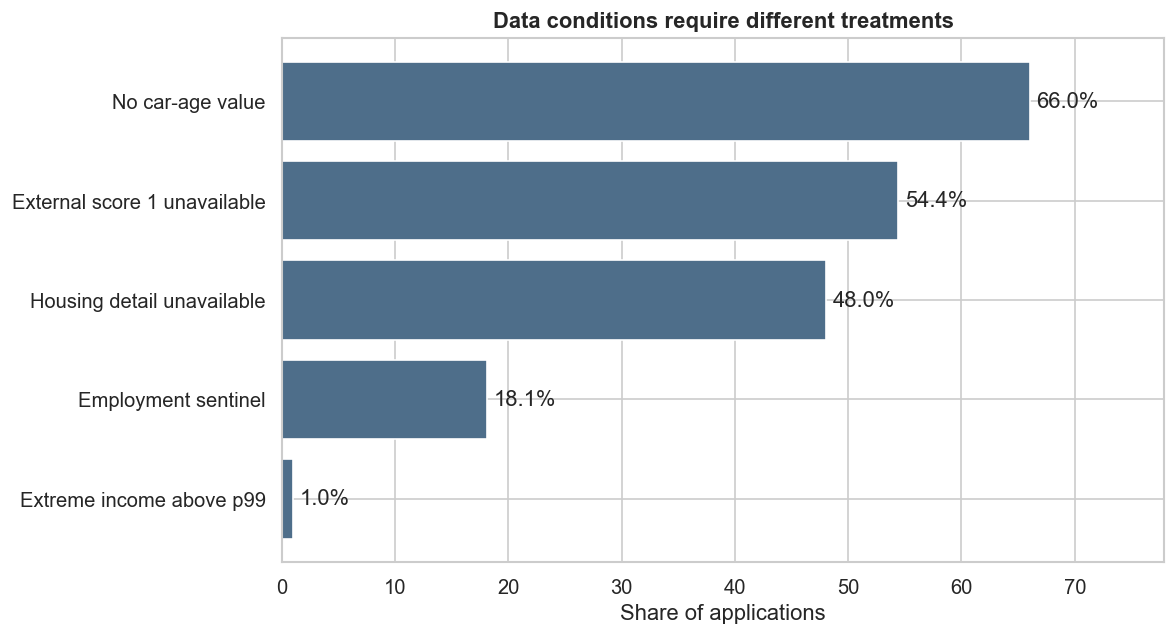

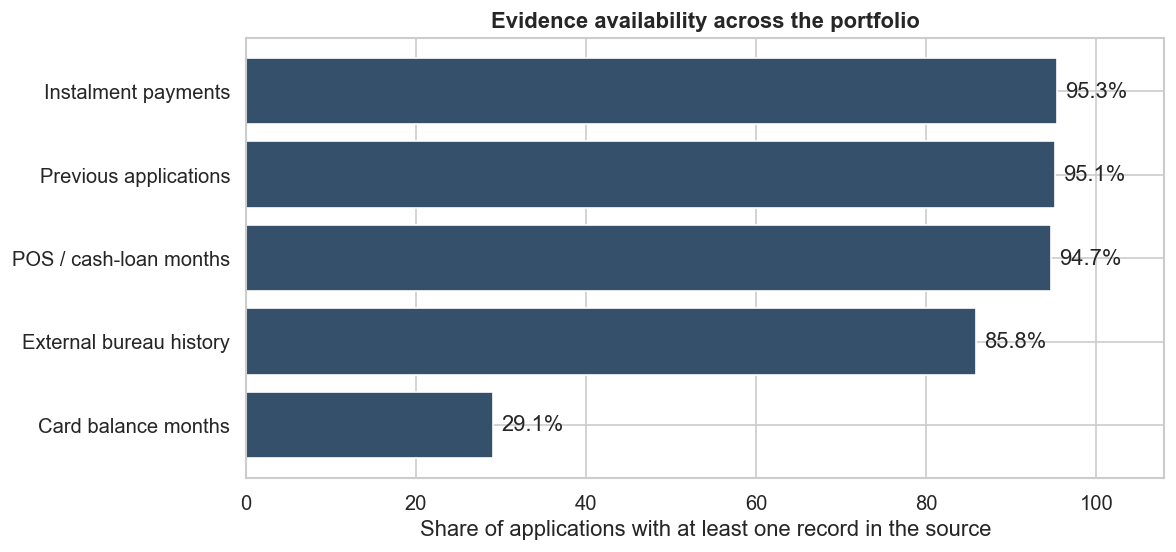

In [16]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
phase1_out = PROJECT_ROOT / 'results/phase1_preprocessing'
phase1_out.mkdir(parents=True, exist_ok=True)

quality_rows = [
    {
        'issue': 'Employment sentinel',
        'affected_rows': int((app['DAYS_EMPLOYED'] == 365243).sum()),
        'affected_share': float((app['DAYS_EMPLOYED'] == 365243).mean()),
        'business_meaning': 'Pensioner or non-employed status marker, not 1,000 years of work',
        'treatment': 'Replace with missing duration and retain a sentinel flag',
    },
    {
        'issue': 'External score 1 unavailable',
        'affected_rows': int(app['EXT_SOURCE_1'].isna().sum()),
        'affected_share': float(app['EXT_SOURCE_1'].isna().mean()),
        'business_meaning': 'Score uncertainty or thin information; not adverse behaviour',
        'treatment': 'Median imputation plus an explicit missing-score flag',
    },
    {
        'issue': 'No car-age value',
        'affected_rows': int(app['OWN_CAR_AGE'].isna().sum()),
        'affected_share': float(app['OWN_CAR_AGE'].isna().mean()),
        'business_meaning': 'Usually structural absence because the applicant has no car',
        'treatment': 'Set age to zero and retain a no-car indicator',
    },
    {
        'issue': 'Housing detail unavailable',
        'affected_rows': int(app['TOTALAREA_MODE'].isna().sum()),
        'affected_share': float(app['TOTALAREA_MODE'].isna().mean()),
        'business_meaning': 'Property record not available; not proof of poor credit quality',
        'treatment': 'Structural zero plus one no-housing-data indicator',
    },
    {
        'issue': 'Extreme income above p99',
        'affected_rows': int((app['AMT_INCOME_TOTAL'] > app['AMT_INCOME_TOTAL'].quantile(.99)).sum()),
        'affected_share': float((app['AMT_INCOME_TOTAL'] > app['AMT_INCOME_TOTAL'].quantile(.99)).mean()),
        'business_meaning': 'Rare amount that can dominate Euclidean distance; not automatically an error',
        'treatment': 'Cap the clustering value at p99; preserve the rule and audit trail',
    },
]
quality = pd.DataFrame(quality_rows).sort_values('affected_share', ascending=True)
quality.to_csv(phase1_out / 'data_quality_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(quality['issue'], quality['affected_share'] * 100, color='#4E6E8A')
for bar, value in zip(bars, quality['affected_share'] * 100):
    ax.text(value + .6, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center')
ax.set_xlabel('Share of applications')
ax.set_title('Data conditions require different treatments', fontweight='bold')
ax.set_xlim(0, max(quality['affected_share'] * 100) * 1.18)
plt.tight_layout()
plt.savefig(phase1_out / 'plot_data_quality.png', dpi=160, bbox_inches='tight')
plt.show()

portfolio_context = pd.DataFrame([
    ('Applications', len(app), 'One application portfolio; every phase reads the same population'),
    ('Source files', 8, 'One application table assembled from two files, plus five behavioural history sources across six files'),
    ('History sources per applicant', 5, 'Bureau, previous applications, POS or cash loans, instalments, card balances'),
    ('Applications with a bureau record', app['SK_ID_CURR'].isin(bureau['SK_ID_CURR']).sum(),
     'Evidence availability, not a credit-quality statement'),
], columns=['measure', 'value', 'business_interpretation'])
portfolio_context.to_csv(phase1_out / 'portfolio_context.csv', index=False)

# Evidence availability: which history sources exist for how much of the
# portfolio. Coverage decides what a reviewer can check for an application.
availability = pd.DataFrame([
    ('External bureau history', app['SK_ID_CURR'].isin(bureau['SK_ID_CURR']).mean()),
    ('Previous applications', app['SK_ID_CURR'].isin(prev['SK_ID_CURR']).mean()),
    ('POS / cash-loan months', app['SK_ID_CURR'].isin(pos['SK_ID_CURR']).mean()),
    ('Instalment payments', app['SK_ID_CURR'].isin(inst['SK_ID_CURR']).mean()),
    ('Card balance months', app['SK_ID_CURR'].isin(cc['SK_ID_CURR']).mean()),
], columns=['source', 'coverage']).sort_values('coverage')

fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh(availability['source'], availability['coverage'] * 100, color='#34506B')
for bar, value in zip(bars, availability['coverage'] * 100):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center')
ax.set_xlabel('Share of applications with at least one record in the source')
ax.set_title('Evidence availability across the portfolio', fontweight='bold')
ax.set_xlim(0, 108)
plt.tight_layout()
plt.savefig(phase1_out / 'plot_evidence_availability.png', dpi=160, bbox_inches='tight')
plt.show()


---
## Preprocessing contract: source evidence versus mining geometry

Broad portfolio segments and record investigations need different versions
of extreme values. The clustering matrix bounds continuous distance axes at
the 0.5th and 99.5th percentiles so a few extreme histories do not consume a
K-Means centroid. The business artifact separately retains `SOURCE_*` values
and external-score missingness flags, so a reviewer sees the supplied value
or true absence rather than a cap or imputation. The out-of-scope outcome
column from the source packaging is dropped at ingestion and never read by
any later phase.


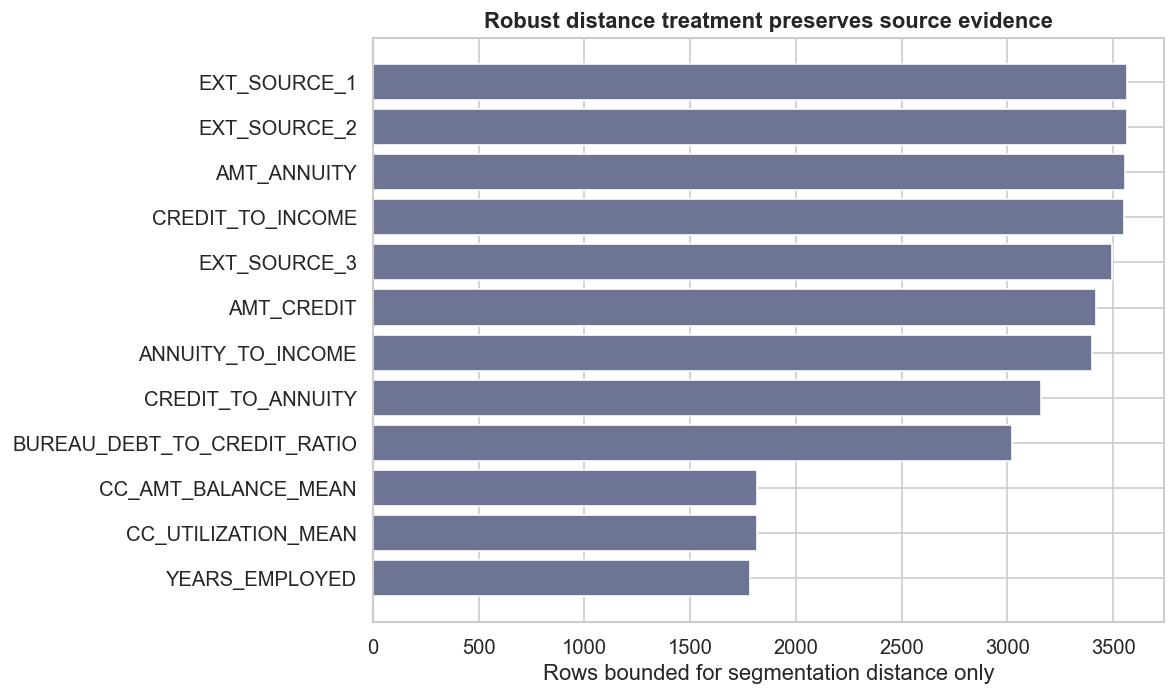

Preserved source columns: ['SOURCE_EXT_SOURCE_1', 'SOURCE_EXT_SOURCE_2', 'SOURCE_EXT_SOURCE_3', 'SOURCE_AMT_INCOME_TOTAL', 'SOURCE_AMT_REQ_CREDIT_BUREAU_MON', 'SOURCE_AMT_REQ_CREDIT_BUREAU_QRT', 'SOURCE_AMT_REQ_CREDIT_BUREAU_YEAR', 'SOURCE_AMT_CREDIT', 'SOURCE_AMT_ANNUITY', 'SOURCE_AMT_GOODS_PRICE']
External-score availability flags: ['FLAG_EXT_SOURCE_1_MISSING', 'FLAG_EXT_SOURCE_2_MISSING', 'FLAG_EXT_SOURCE_3_MISSING']


In [17]:
clip_audit = pd.read_csv(phase1_out / 'clustering_clip_limits.csv')
clip_audit['total_rows_bounded'] = clip_audit['rows_clipped_low'] + clip_audit['rows_clipped_high']
plot_clip = clip_audit.nlargest(12, 'total_rows_bounded').sort_values('total_rows_bounded')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_clip['feature'], plot_clip['total_rows_bounded'], color='#6E7493')
ax.set_xlabel('Rows bounded for segmentation distance only')
ax.set_title('Robust distance treatment preserves source evidence', fontweight='bold')
plt.tight_layout(); plt.savefig(phase1_out / 'plot_clustering_clip_audit.png', dpi=160, bbox_inches='tight'); plt.show()

business_contract = pd.read_csv(
    PROJECT_ROOT / 'datasets/final/features_business.csv', nrows=5)
source_cols = [c for c in business_contract.columns if c.startswith('SOURCE_')]
score_flags = [c for c in business_contract.columns if c.startswith('FLAG_EXT_SOURCE_')]
print('Preserved source columns:', source_cols)
print('External-score availability flags:', score_flags)
